<a href="https://www.kaggle.com/code/omborse771924/gta-v-worldwide-sales-player-analytics-eda?scriptVersionId=332709265" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/velvetcrystal/gta-v-worldwide-sales-and-player-analytics/gta_v_worldwide_sales_player_analytics_2013_2026.csv


## Loading Dataset

In [2]:
df =  pd.read_csv('/kaggle/input/datasets/velvetcrystal/gta-v-worldwide-sales-and-player-analytics/gta_v_worldwide_sales_player_analytics_2013_2026.csv')

In [3]:
df.head()

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,...,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
0,GTA5-100039,2013,9,3,Algeria,DZA,Africa,PS3,Premium Edition,Physical,...,4.82,38.28,5621.76,Launch,41.4,58.6,Autumn,Xbox Sale,Action-Adventure,Gen7
1,GTA5-100005,2013,9,3,Argentina,ARG,South America,PS3,Standard Edition,Physical,...,23.48,42.31,14452.74,Launch,40.8,59.2,Autumn,Xbox Sale,Action-Adventure,Gen7
2,GTA5-100093,2013,9,3,Argentina,ARG,South America,Xbox 360,Premium Edition,Physical,...,23.96,42.31,14748.61,Launch,51.6,48.4,Autumn,Xbox Sale,Action-Adventure,Gen7
3,GTA5-100072,2013,9,3,Armenia,ARM,Asia,PS3,Standard Edition,Physical,...,0.14,2.92,3879.16,Launch,42.3,57.7,Autumn,Xbox Sale,Action-Adventure,Gen7
4,GTA5-100034,2013,9,3,Australia,AUS,Oceania,PS3,Legacy Edition,Physical,...,231.44,23.17,69365.83,Launch,43.4,56.6,Autumn,Xbox Sale,Action-Adventure,Gen7


In [4]:
df.tail()

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,...,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
14775,GTA5-114683,2026,6,2,United States,USA,North America,PC,Premium Edition,Digital,...,7671.76,365.96,65510.55,Legacy,48.8,51.2,Summer,Steam Summer Sale,Action-Adventure,PC
14776,GTA5-114771,2026,6,2,United States,USA,North America,Xbox Series X|S,Standard Edition,Digital,...,7555.14,365.96,64514.73,Growth,41.5,58.5,Summer,Steam Summer Sale,Action-Adventure,Gen9
14777,GTA5-114691,2026,6,2,Uruguay,URY,South America,PC,Standard Edition,Digital,...,0.79,3.94,20815.83,Legacy,59.9,40.1,Summer,Steam Summer Sale,Action-Adventure,PC
14778,GTA5-114779,2026,6,2,Uruguay,URY,South America,Xbox Series X|S,Standard Edition,Digital,...,0.77,3.94,20269.18,Growth,47.7,52.3,Summer,Steam Summer Sale,Action-Adventure,Gen9
14779,GTA5-114713,2026,6,2,Vietnam,VNM,Asia,Xbox Series X|S,Standard Edition,Digital,...,24.48,104.23,4317.13,Growth,45.6,54.4,Summer,Steam Summer Sale,Action-Adventure,Gen9


In [5]:
df.describe()

,year,month,quarter,units_sold,gross_revenue_usd,average_selling_price_usd,discount_percentage,digital_sales_percentage,physical_sales_percentage,new_customers,...,customer_rating,review_count,refund_rate_percentage,exchange_rate_to_usd,internet_penetration_percentage,gaming_market_size,population_millions,gdp_per_capita_usd,weekend_sales_percentage,weekday_sales_percentage
count,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,...,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000
mean,2019.580920,6.525440,2.500406,850.437483,11571.717520,15.106273,36.843965,61.494729,38.505271,352.793234,...,4.550257,15.848241,3.489408,1582.759206,96.711482,230.757881,77.162503,25814.493173,46.087375,53.912625
std,3.724658,3.480096,1.122421,993.338857,13668.030082,6.879634,17.374816,15.419953,15.419953,423.222350,...,0.139301,20.413230,1.478754,9500.887243,5.542113,952.079706,208.491117,24690.139324,4.998563,4.998563
min,2013.000000,1.000000,1.000000,23.000000,176.000000,3.000000,0.000000,27.600000,1.000000,9.000000,...,4.200000,3.000000,0.100000,0.301500,37.000000,0.030000,0.330000,606.780000,30.000000,35.300000
25%,2016.000000,3.000000,1.000000,272.000000,3761.280000,9.760000,25.600000,48.500000,27.600000,111.000000,...,4.457500,4.000000,2.460000,0.912975,98.000000,1.740000,6.320000,6710.667500,42.800000,50.600000
50%,2020.000000,6.000000,2.000000,522.000000,7262.900000,13.525000,40.900000,61.900000,38.100000,216.000000,...,4.550000,9.000000,3.480000,5.073300,98.000000,12.465000,21.470000,16690.350000,46.100000,53.900000
75%,2023.000000,10.000000,4.000000,1029.000000,13845.237500,18.710000,49.500000,72.400000,51.500000,421.000000,...,4.640000,19.000000,4.490000,109.060850,98.000000,52.417500,60.342500,43135.320000,49.400000,57.200000
max,2026.000000,12.000000,4.000000,11130.000000,167483.250000,39.990000,80.000000,99.000000,72.400000,5782.000000,...,5.000000,271.000000,9.360000,91627.528800,98.000000,7729.210000,1605.120000,120894.830000,64.700000,70.000000


In [6]:
df.isnull

<bound method DataFrame.isnull of       transaction_id  year  month  quarter        country iso3_code  \
0        GTA5-100039  2013      9        3        Algeria       DZA   
1        GTA5-100005  2013      9        3      Argentina       ARG   
2        GTA5-100093  2013      9        3      Argentina       ARG   
3        GTA5-100072  2013      9        3        Armenia       ARM   
4        GTA5-100034  2013      9        3      Australia       AUS   
...              ...   ...    ...      ...            ...       ...   
14775    GTA5-114683  2026      6        2  United States       USA   
14776    GTA5-114771  2026      6        2  United States       USA   
14777    GTA5-114691  2026      6        2        Uruguay       URY   
14778    GTA5-114779  2026      6        2        Uruguay       URY   
14779    GTA5-114713  2026      6        2        Vietnam       VNM   

              region         platform      game_edition sales_channel  ...  \
0             Africa              P

In [7]:
df.isnull().sum()

transaction_id                        0
year                                  0
month                                 0
quarter                               0
country                               0
iso3_code                             0
region                                0
platform                              0
game_edition                          0
sales_channel                         0
retailer                              0
units_sold                            0
gross_revenue_usd                     0
average_selling_price_usd             0
discount_percentage                   0
digital_sales_percentage              0
physical_sales_percentage             0
new_customers                         0
returning_customers                   0
estimated_active_players              0
peak_concurrent_players               0
online_players                        0
story_mode_players                    0
gta_online_players                    0
dlc_revenue_usd                       0


Missing Values Before Handling
transaction_id                        0
year                                  0
month                                 0
quarter                               0
country                               0
iso3_code                             0
region                                0
platform                              0
game_edition                          0
sales_channel                         0
retailer                              0
units_sold                            0
gross_revenue_usd                     0
average_selling_price_usd             0
discount_percentage                   0
digital_sales_percentage              0
physical_sales_percentage             0
new_customers                         0
returning_customers                   0
estimated_active_players              0
peak_concurrent_players               0
online_players                        0
story_mode_players                    0
gta_online_players                    0
dlc_reven

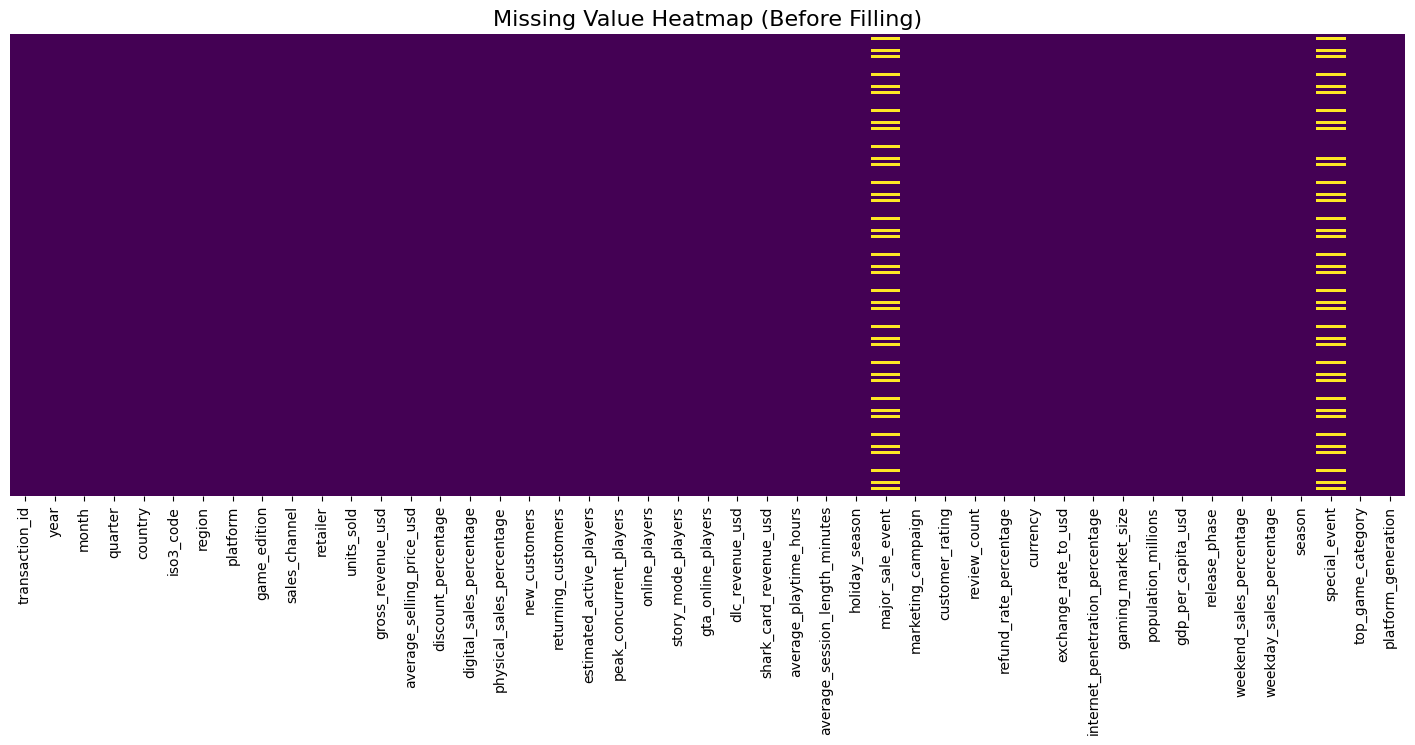

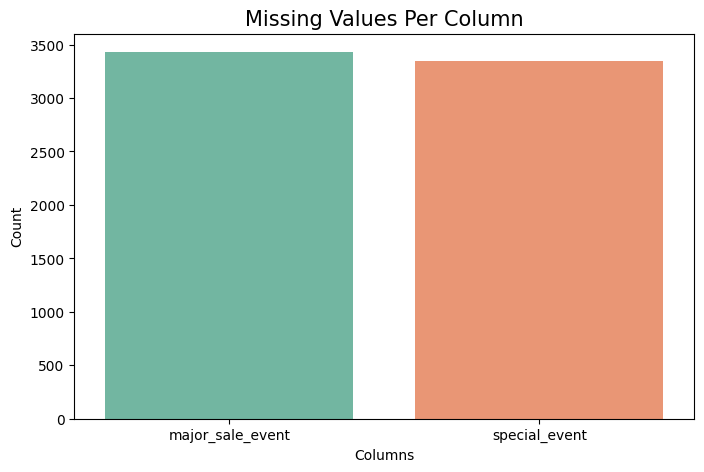

Missing Values After Handling
transaction_id                     0
year                               0
month                              0
quarter                            0
country                            0
iso3_code                          0
region                             0
platform                           0
game_edition                       0
sales_channel                      0
retailer                           0
units_sold                         0
gross_revenue_usd                  0
average_selling_price_usd          0
discount_percentage                0
digital_sales_percentage           0
physical_sales_percentage          0
new_customers                      0
returning_customers                0
estimated_active_players           0
peak_concurrent_players            0
online_players                     0
story_mode_players                 0
gta_online_players                 0
dlc_revenue_usd                    0
shark_card_revenue_usd             0
average_

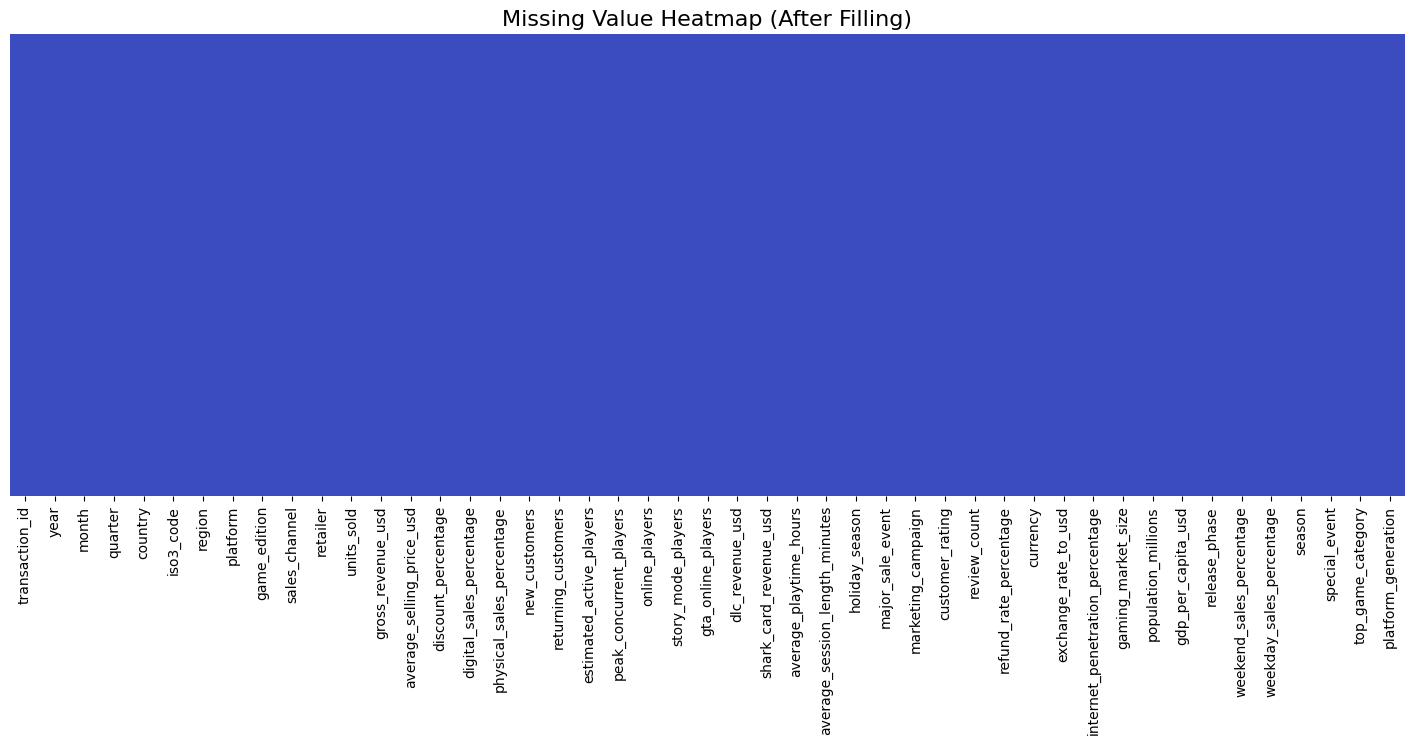


✅ No Missing Values Remaining in the Dataset.


In [8]:
# ==========================================================
# MISSING VALUE HANDLING
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# CHECK MISSING VALUES
# ==========================================================

print("=" * 60)
print("Missing Values Before Handling")
print("=" * 60)

missing_values = df.isnull().sum()
print(missing_values)

# ==========================================================
# MISSING VALUE PERCENTAGE
# ==========================================================

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

print("\nColumns with Missing Values")
print(missing_df)

# ==========================================================
# VISUALIZE MISSING VALUES (BEFORE)
# ==========================================================

plt.figure(figsize=(18,6))

sns.heatmap(
    df.isnull(),
    cmap='viridis',
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap (Before Filling)", fontsize=16)
plt.show()

# ==========================================================
# BAR CHART OF MISSING VALUES
# ==========================================================

if len(missing_df) > 0:

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=missing_df.index,
        y=missing_df['Missing Values'],
        palette='Set2'
    )

    plt.title("Missing Values Per Column", fontsize=15)
    plt.ylabel("Count")
    plt.xlabel("Columns")

    plt.show()

# ==========================================================
# FILL MISSING VALUES
# ==========================================================

df['major_sale_event'] = df['major_sale_event'].fillna('No Sale Event')

df['special_event'] = df['special_event'].fillna('No Special Event')

# ==========================================================
# VERIFY MISSING VALUES
# ==========================================================

print("=" * 60)
print("Missing Values After Handling")
print("=" * 60)

print(df.isnull().sum())

# ==========================================================
# VISUALIZE AFTER FILLING
# ==========================================================

plt.figure(figsize=(18,6))

sns.heatmap(
    df.isnull(),
    cmap='coolwarm',
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap (After Filling)", fontsize=16)
plt.show()

# ==========================================================
# FINAL CHECK
# ==========================================================

if df.isnull().sum().sum() == 0:
    print("\n✅ No Missing Values Remaining in the Dataset.")
else:
    print("\n⚠️ Some Missing Values Still Exist.")

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14775    False
14776    False
14777    False
14778    False
14779    False
Length: 14780, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['transaction_id', 'year', 'month', 'quarter', 'country', 'iso3_code',
       'region', 'platform', 'game_edition', 'sales_channel', 'retailer',
       'units_sold', 'gross_revenue_usd', 'average_selling_price_usd',
       'discount_percentage', 'digital_sales_percentage',
       'physical_sales_percentage', 'new_customers', 'returning_customers',
       'estimated_active_players', 'peak_concurrent_players', 'online_players',
       'story_mode_players', 'gta_online_players', 'dlc_revenue_usd',
       'shark_card_revenue_usd', 'average_playtime_hours',
       'average_session_length_minutes', 'holiday_season', 'major_sale_event',
       'marketing_campaign', 'customer_rating', 'review_count',
       'refund_rate_percentage', 'currency', 'exchange_rate_to_usd',
       'internet_penetration_percentage', 'gaming_market_size',
       'population_millions', 'gdp_per_capita_usd', 'release_phase',
       'weekend_sales_percentage', 'weekday_sales_percentage', 'season',
       'special_e

## EDA

Dataset Shape
(14780, 47)

Data Types
transaction_id                      object
year                                 int64
month                                int64
quarter                              int64
country                             object
iso3_code                           object
region                              object
platform                            object
game_edition                        object
sales_channel                       object
retailer                            object
units_sold                           int64
gross_revenue_usd                  float64
average_selling_price_usd          float64
discount_percentage                float64
digital_sales_percentage           float64
physical_sales_percentage          float64
new_customers                        int64
returning_customers                  int64
estimated_active_players             int64
peak_concurrent_players              int64
online_players                       int64
story_mode_playe

,year,month,quarter,units_sold,gross_revenue_usd,average_selling_price_usd,discount_percentage,digital_sales_percentage,physical_sales_percentage,new_customers,...,customer_rating,review_count,refund_rate_percentage,exchange_rate_to_usd,internet_penetration_percentage,gaming_market_size,population_millions,gdp_per_capita_usd,weekend_sales_percentage,weekday_sales_percentage
count,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,...,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000,14780.000000
mean,2019.580920,6.525440,2.500406,850.437483,11571.717520,15.106273,36.843965,61.494729,38.505271,352.793234,...,4.550257,15.848241,3.489408,1582.759206,96.711482,230.757881,77.162503,25814.493173,46.087375,53.912625
std,3.724658,3.480096,1.122421,993.338857,13668.030082,6.879634,17.374816,15.419953,15.419953,423.222350,...,0.139301,20.413230,1.478754,9500.887243,5.542113,952.079706,208.491117,24690.139324,4.998563,4.998563
min,2013.000000,1.000000,1.000000,23.000000,176.000000,3.000000,0.000000,27.600000,1.000000,9.000000,...,4.200000,3.000000,0.100000,0.301500,37.000000,0.030000,0.330000,606.780000,30.000000,35.300000
25%,2016.000000,3.000000,1.000000,272.000000,3761.280000,9.760000,25.600000,48.500000,27.600000,111.000000,...,4.457500,4.000000,2.460000,0.912975,98.000000,1.740000,6.320000,6710.667500,42.800000,50.600000
50%,2020.000000,6.000000,2.000000,522.000000,7262.900000,13.525000,40.900000,61.900000,38.100000,216.000000,...,4.550000,9.000000,3.480000,5.073300,98.000000,12.465000,21.470000,16690.350000,46.100000,53.900000
75%,2023.000000,10.000000,4.000000,1029.000000,13845.237500,18.710000,49.500000,72.400000,51.500000,421.000000,...,4.640000,19.000000,4.490000,109.060850,98.000000,52.417500,60.342500,43135.320000,49.400000,57.200000
max,2026.000000,12.000000,4.000000,11130.000000,167483.250000,39.990000,80.000000,99.000000,72.400000,5782.000000,...,5.000000,271.000000,9.360000,91627.528800,98.000000,7729.210000,1605.120000,120894.830000,64.700000,70.000000



Numerical Columns: 32
Index(['year', 'month', 'quarter', 'units_sold', 'gross_revenue_usd',
       'average_selling_price_usd', 'discount_percentage',
       'digital_sales_percentage', 'physical_sales_percentage',
       'new_customers', 'returning_customers', 'estimated_active_players',
       'peak_concurrent_players', 'online_players', 'story_mode_players',
       'gta_online_players', 'dlc_revenue_usd', 'shark_card_revenue_usd',
       'average_playtime_hours', 'average_session_length_minutes',
       'holiday_season', 'marketing_campaign', 'customer_rating',
       'review_count', 'refund_rate_percentage', 'exchange_rate_to_usd',
       'internet_penetration_percentage', 'gaming_market_size',
       'population_millions', 'gdp_per_capita_usd', 'weekend_sales_percentage',
       'weekday_sales_percentage'],
      dtype='object')

Categorical Columns: 15
Index(['transaction_id', 'country', 'iso3_code', 'region', 'platform',
       'game_edition', 'sales_channel', 'retailer', 'majo

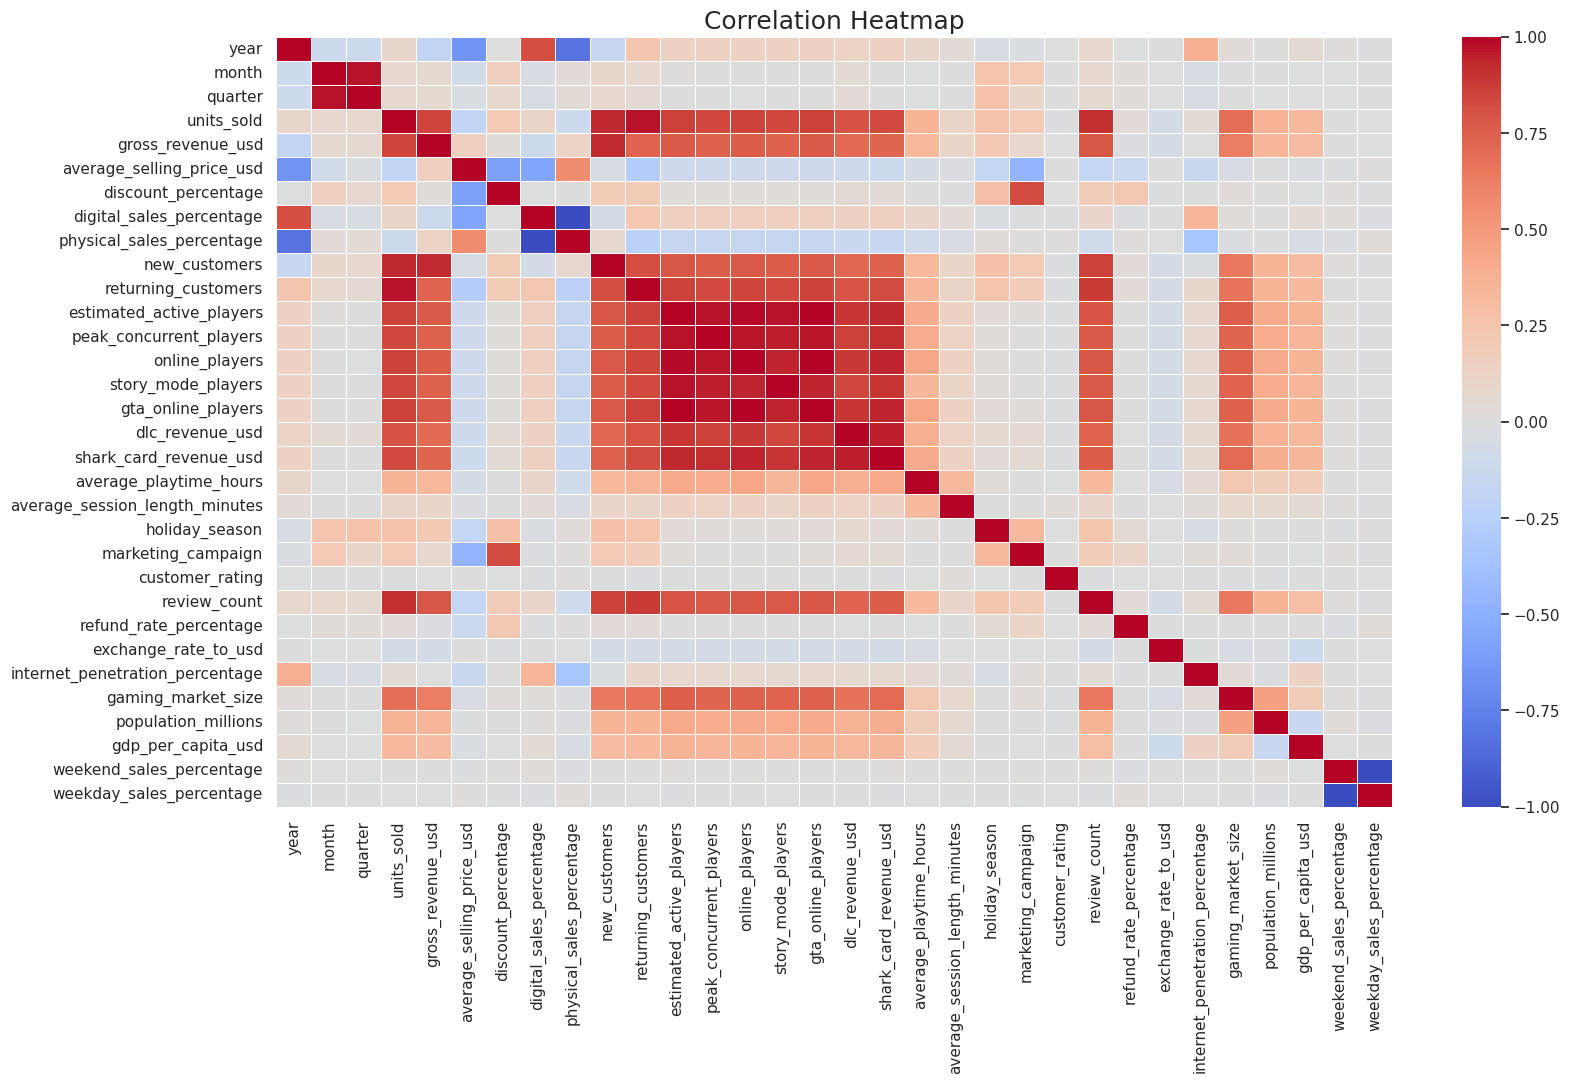

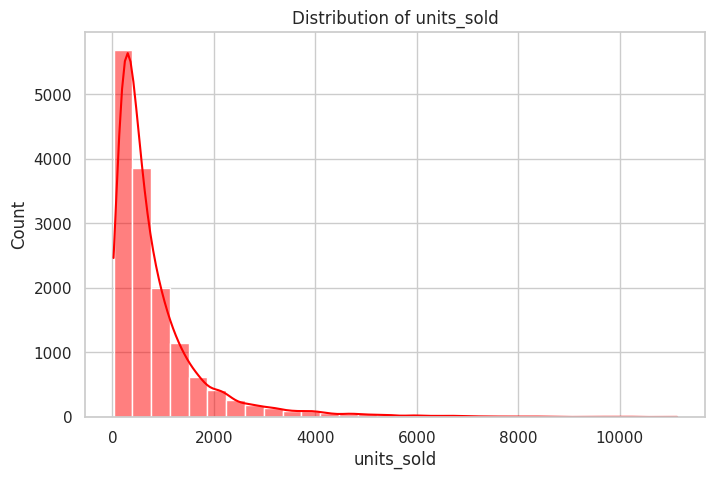

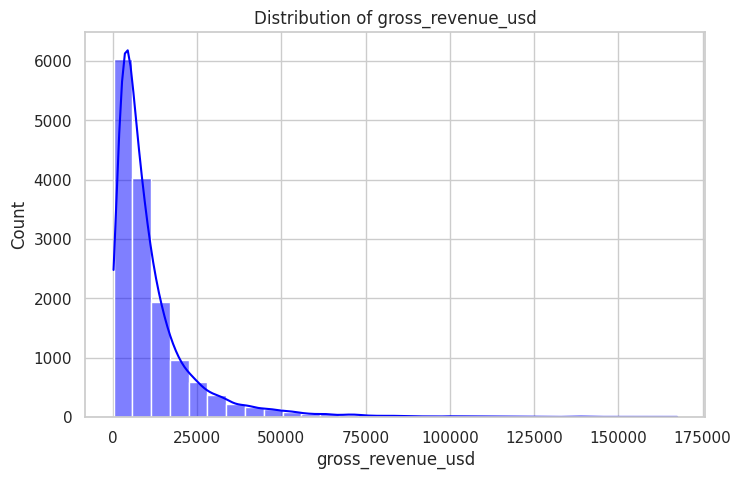

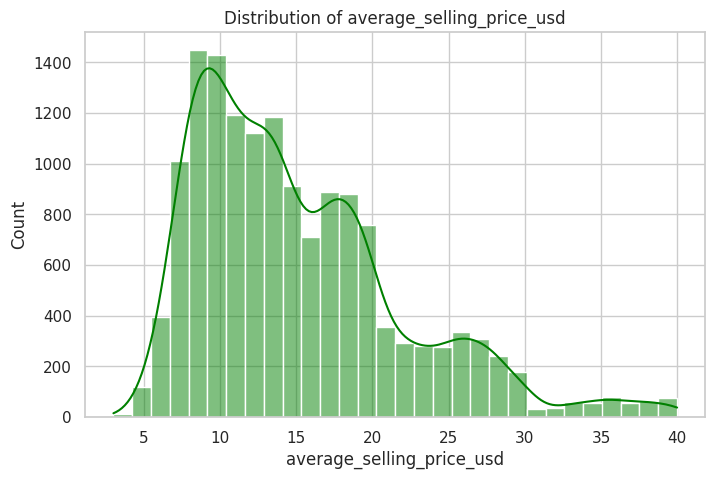

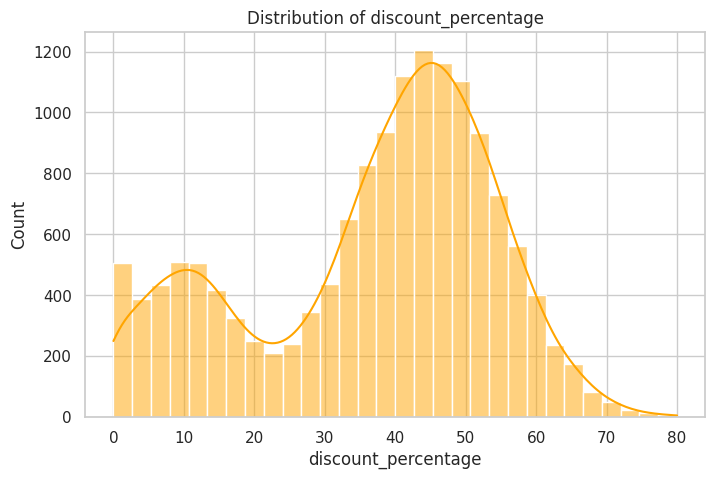

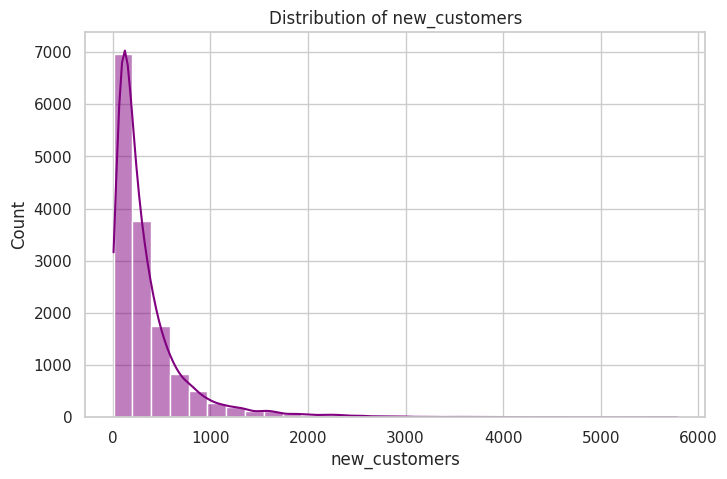

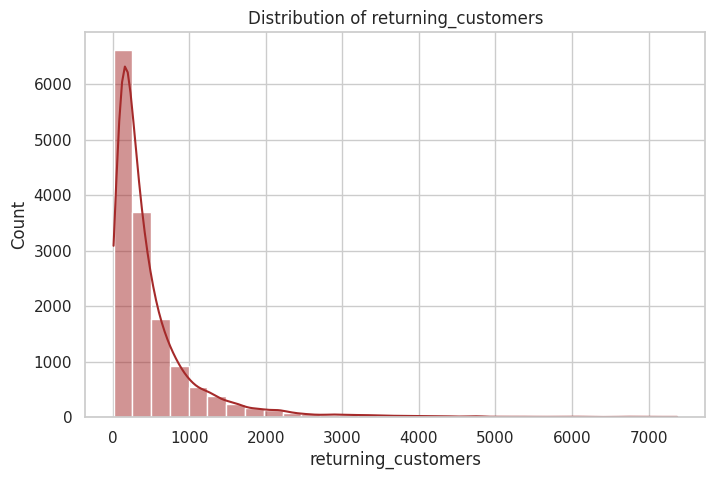

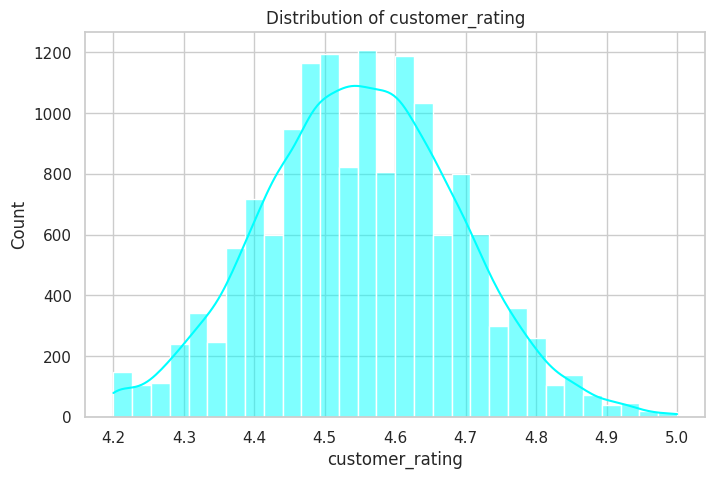

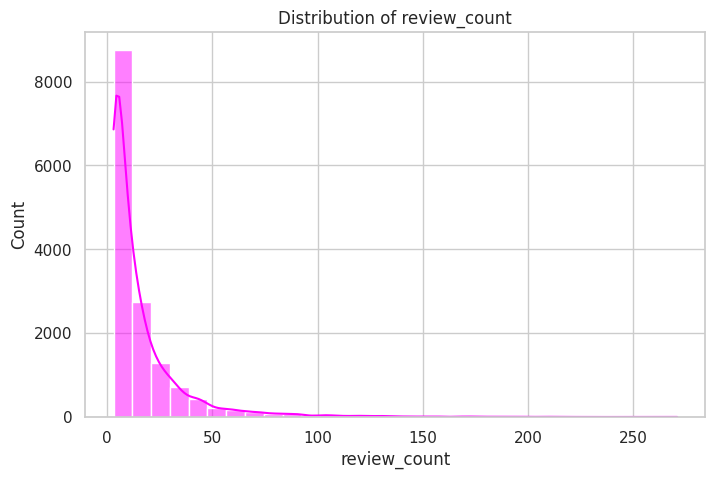

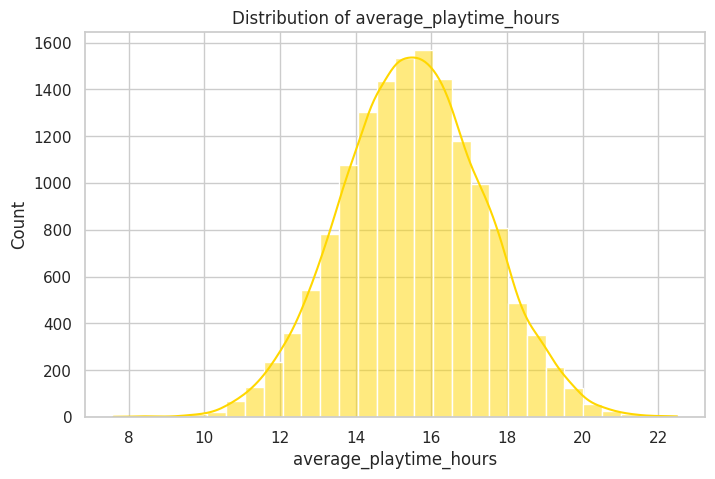

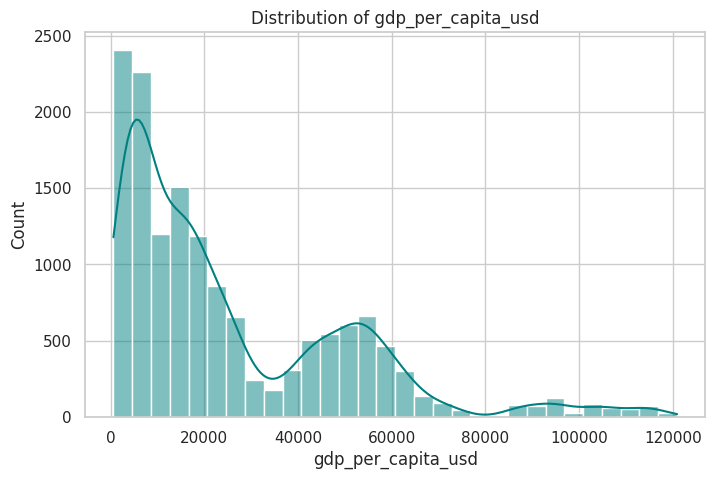

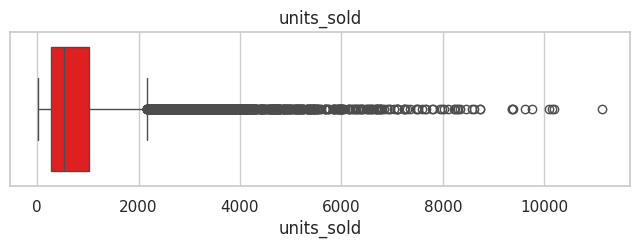

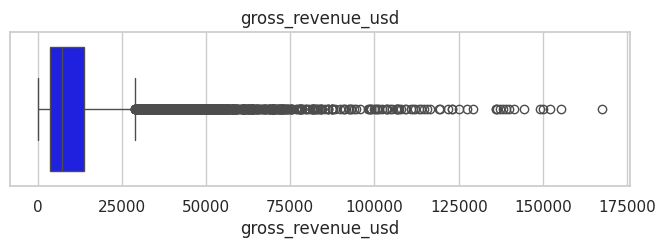

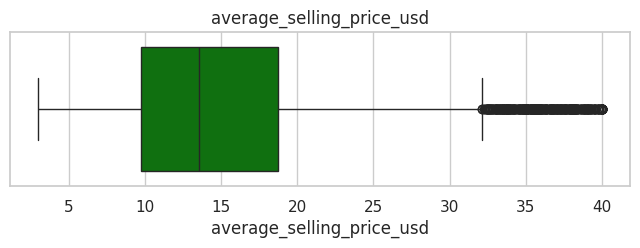

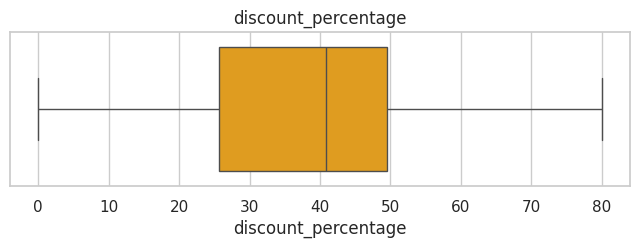

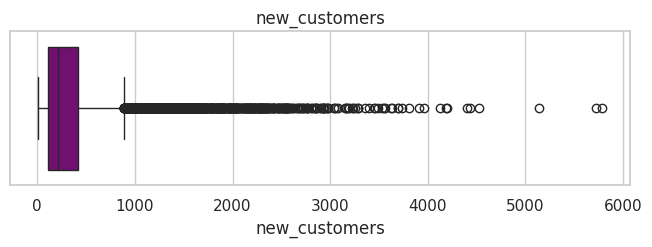

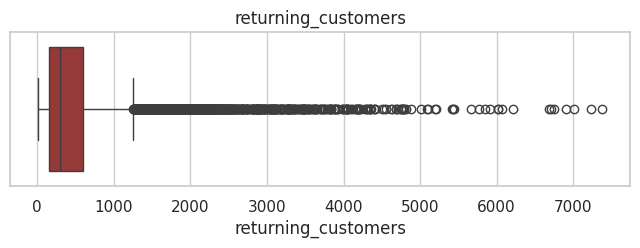

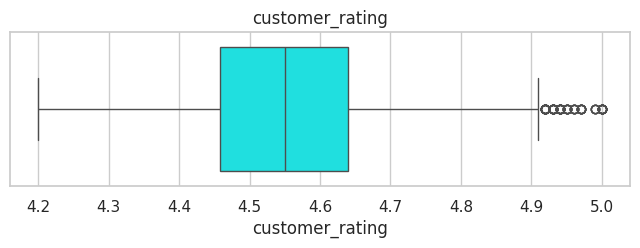

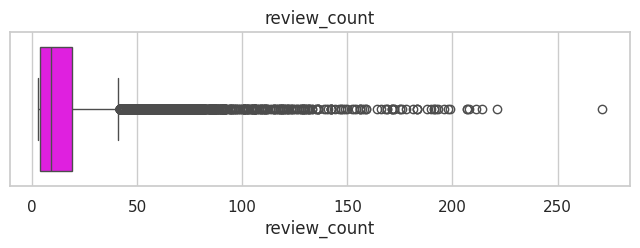

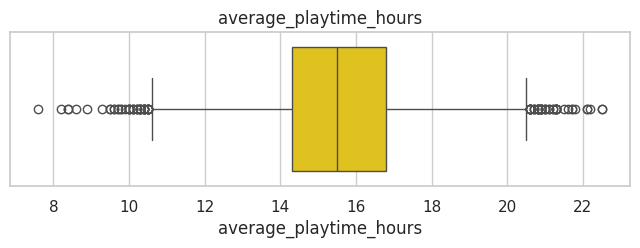

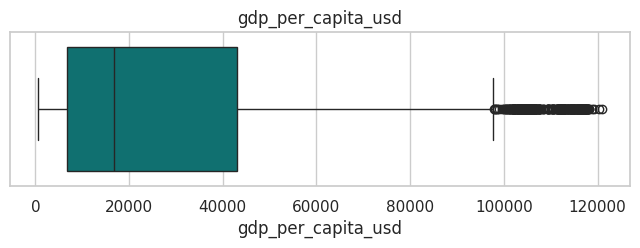

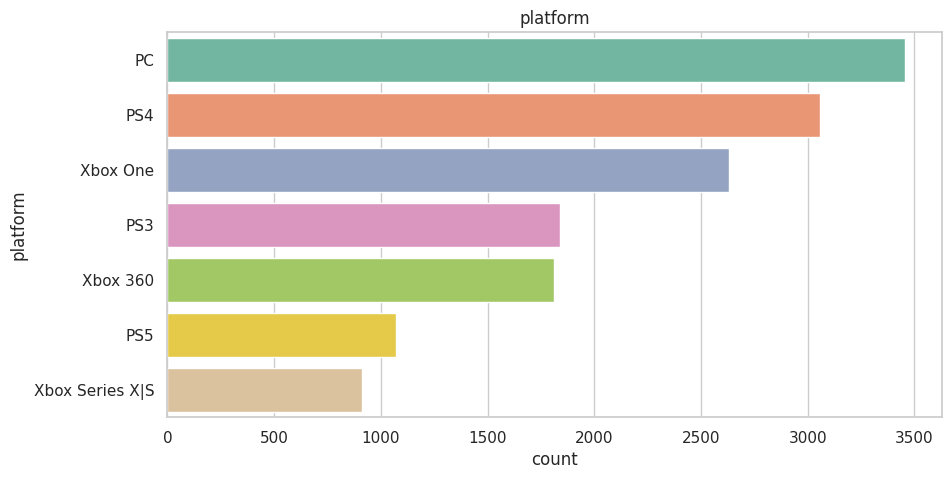

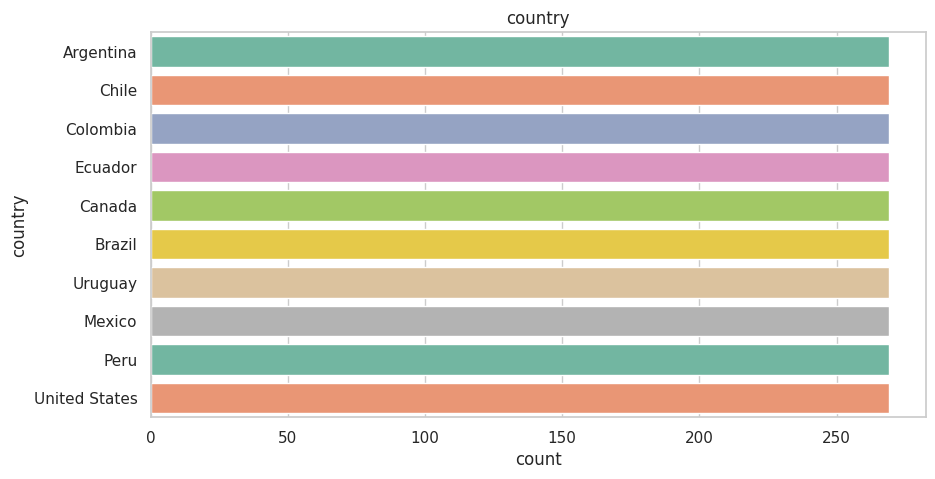

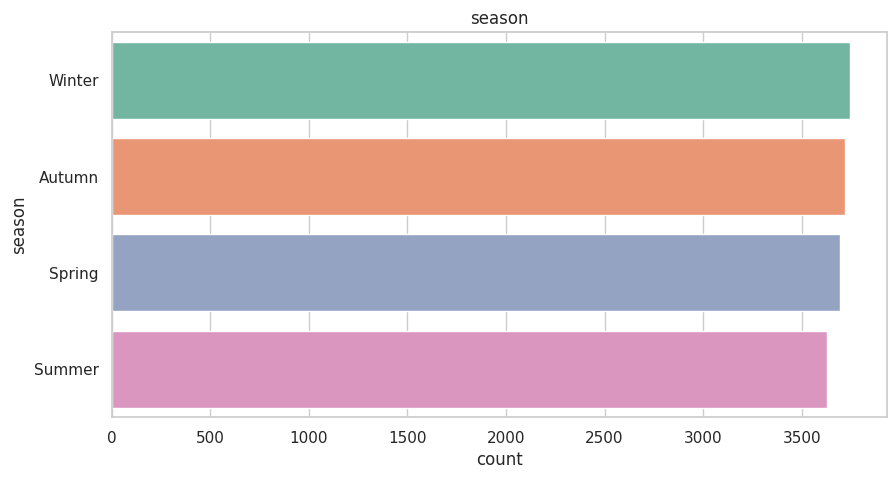

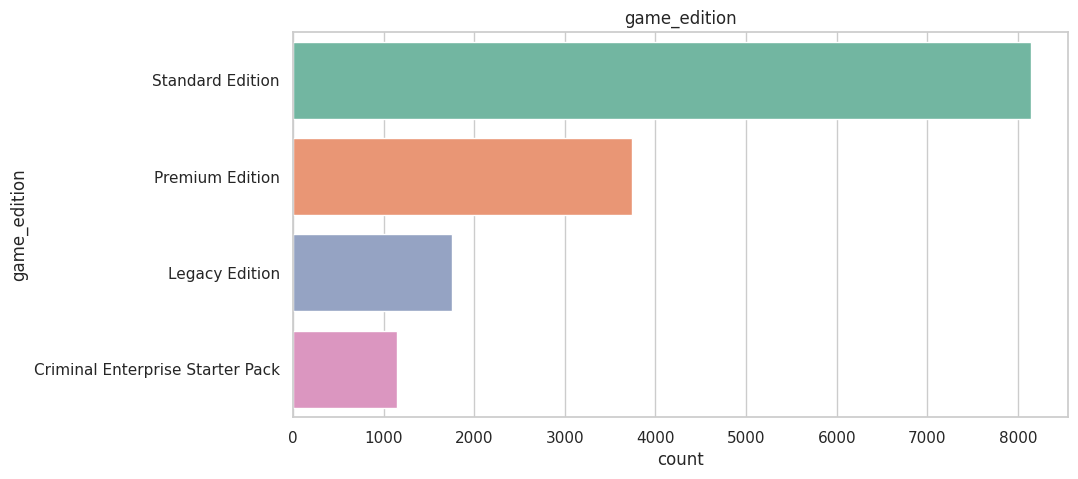

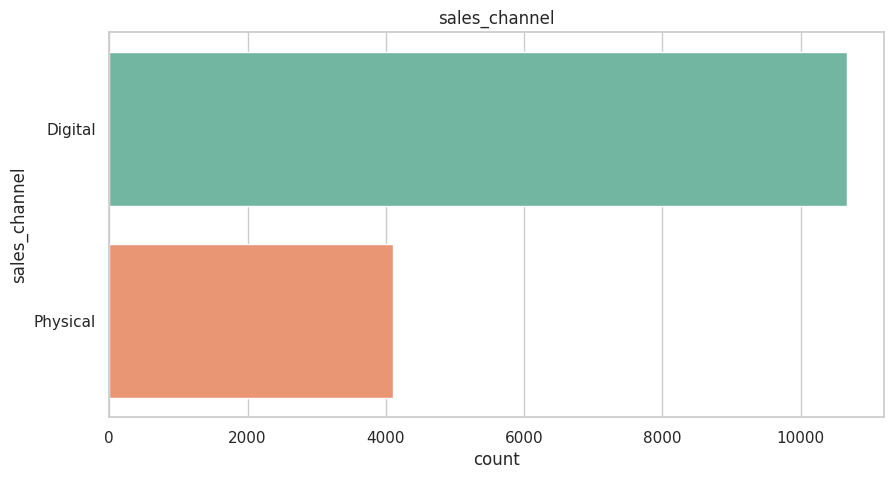

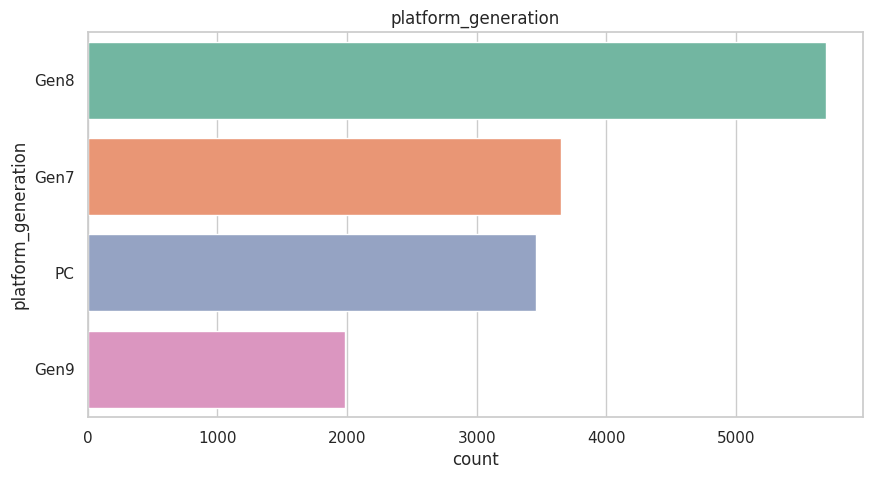

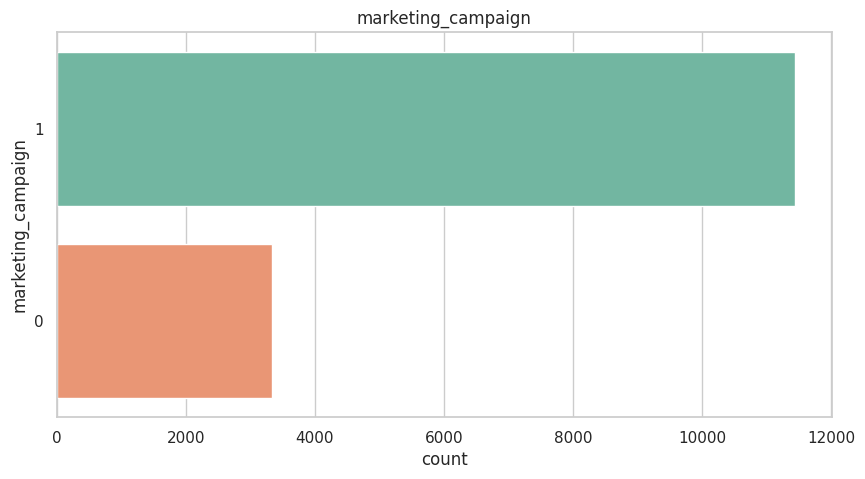

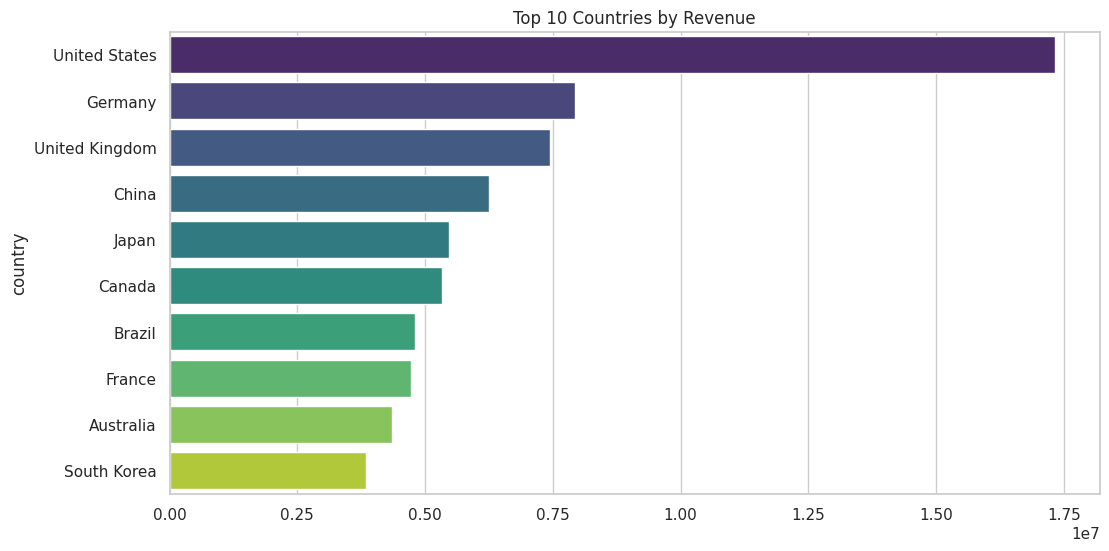

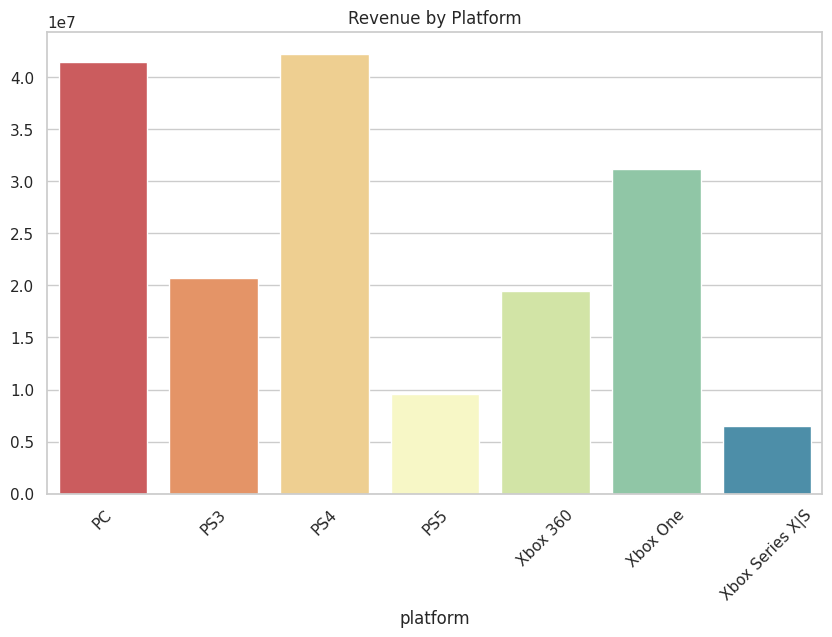

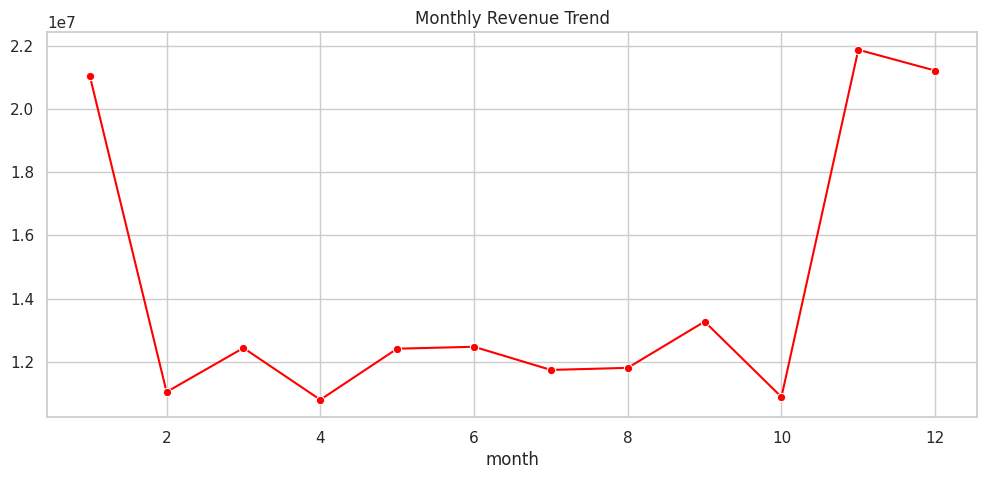

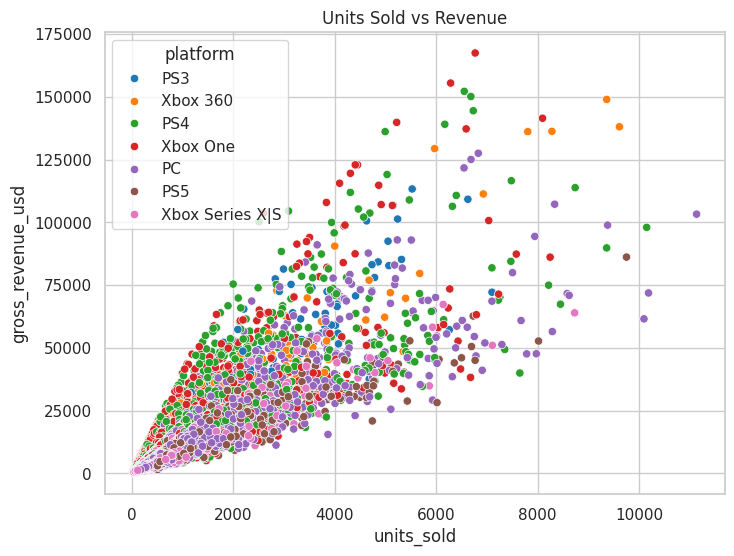

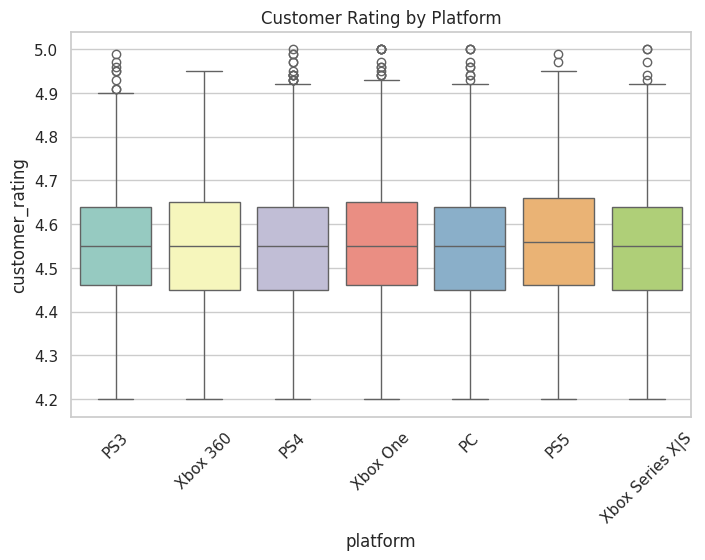

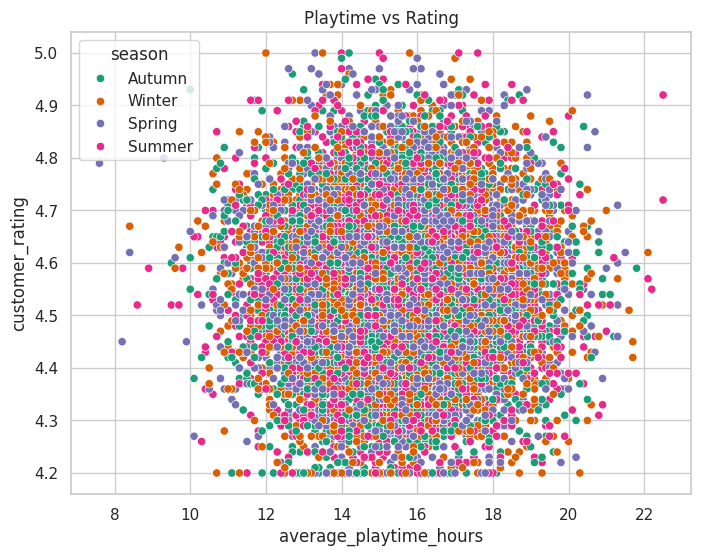

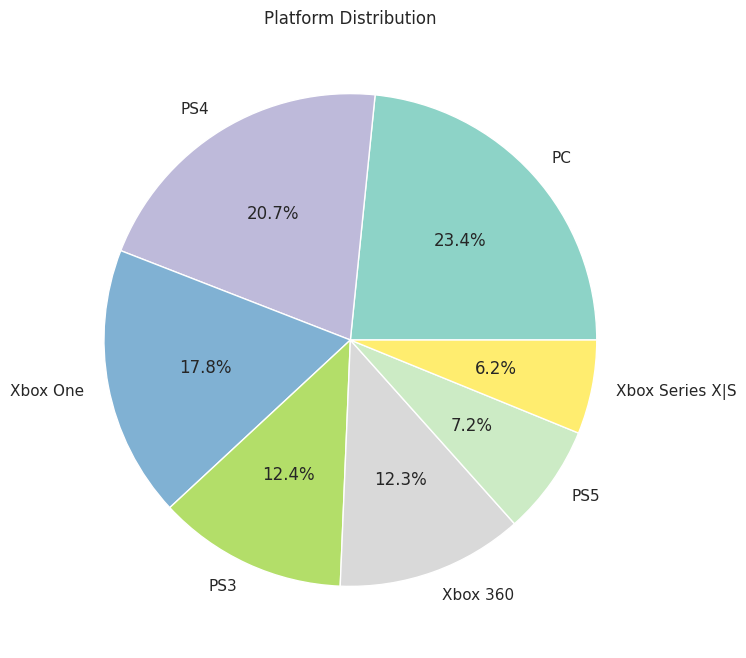

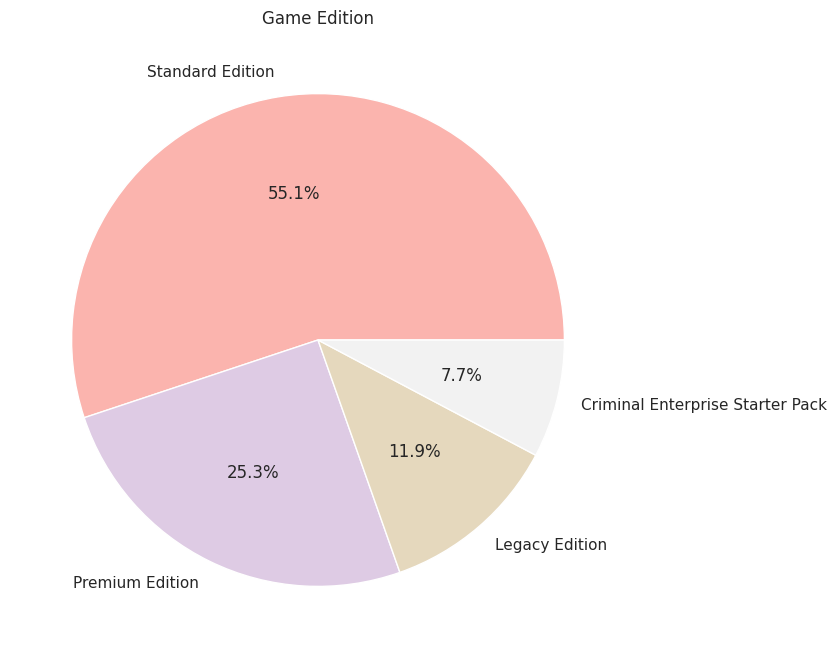

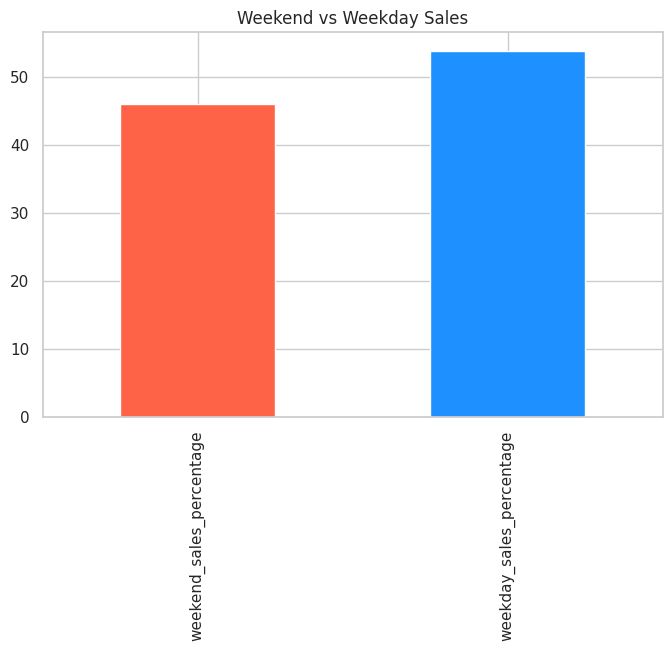

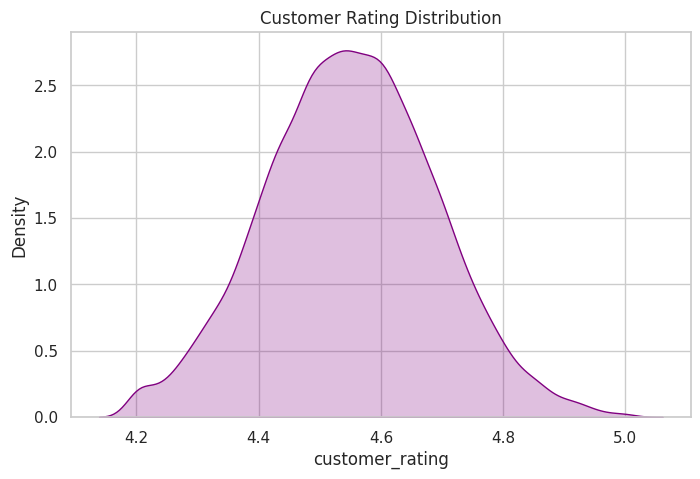

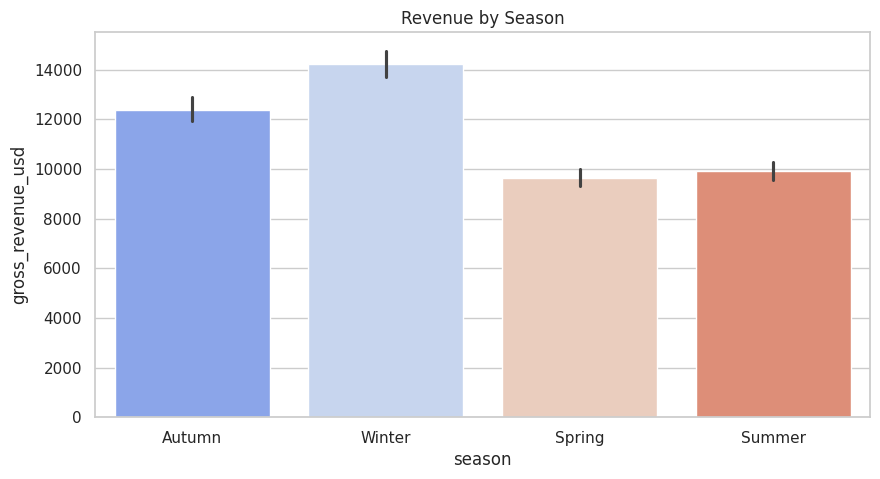

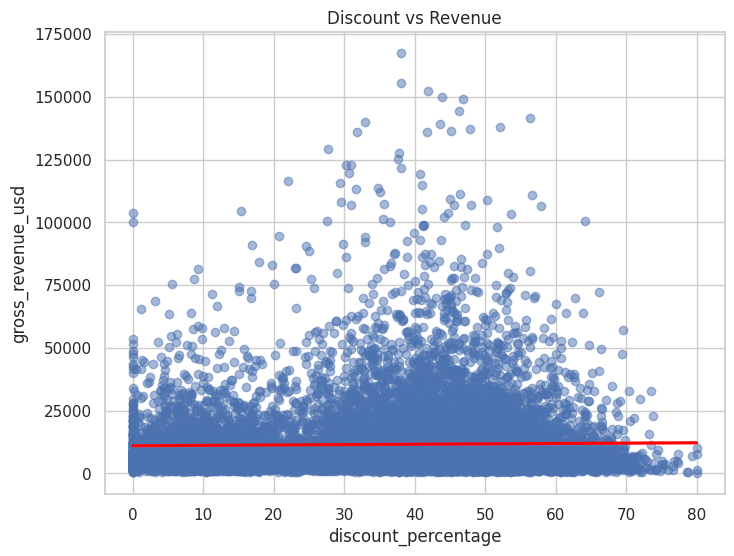

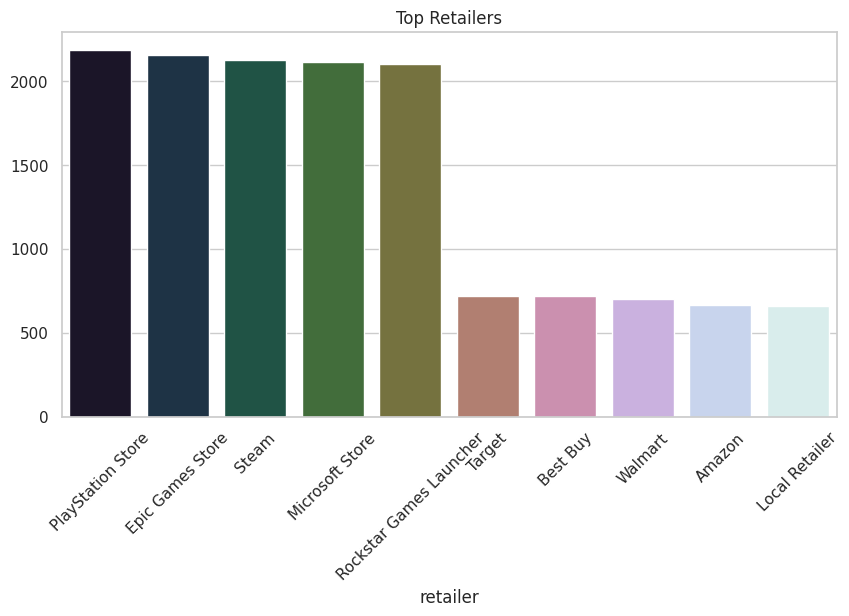

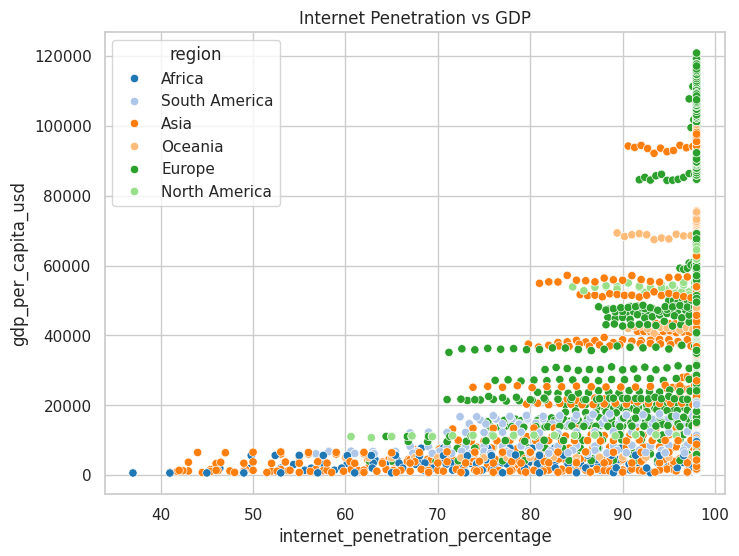

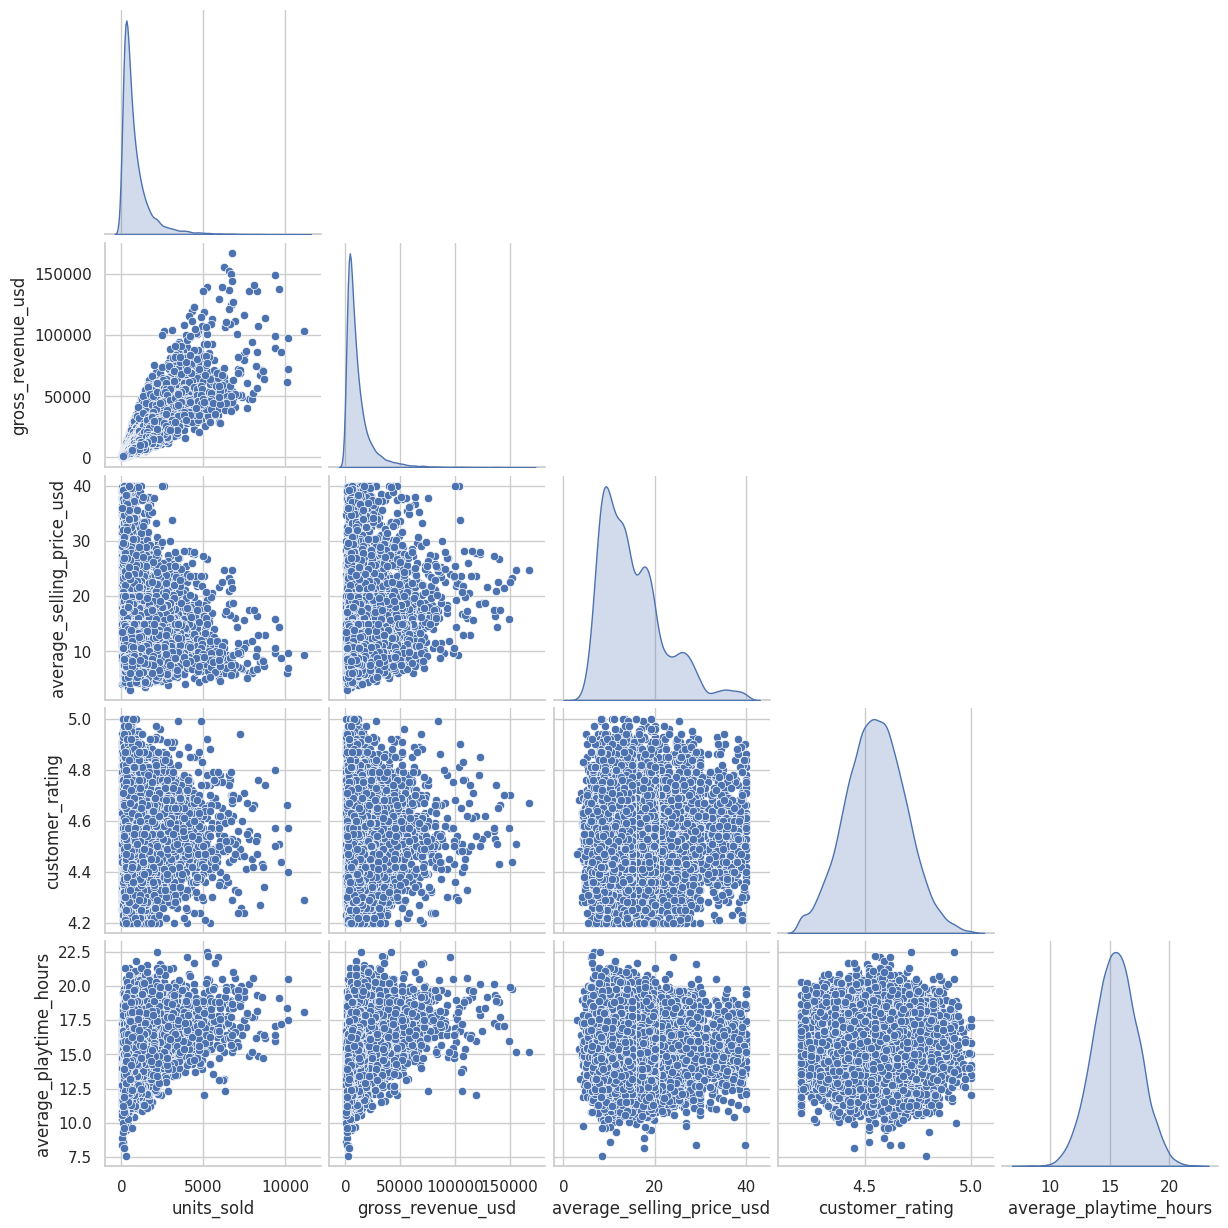

EDA Completed Successfully


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# =====================================================
# BASIC INFORMATION
# =====================================================

print("="*60)
print("Dataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics")
display(df.describe())

# =====================================================
# NUMERICAL & CATEGORICAL COLUMNS
# =====================================================

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("\nNumerical Columns:", len(num_cols))
print(num_cols)

print("\nCategorical Columns:", len(cat_cols))
print(cat_cols)

# =====================================================
# CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(18,10))

sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=.5
)

plt.title("Correlation Heatmap",fontsize=18)
plt.show()

# =====================================================
# HISTOGRAMS
# =====================================================

important_num = [
'units_sold',
'gross_revenue_usd',
'average_selling_price_usd',
'discount_percentage',
'new_customers',
'returning_customers',
'customer_rating',
'review_count',
'average_playtime_hours',
'gdp_per_capita_usd'
]

colors=[
'red','blue','green','orange','purple',
'brown','cyan','magenta','gold','teal'
]

for i,col in enumerate(important_num):

    if col in df.columns:

        plt.figure(figsize=(8,5))

        sns.histplot(
            df[col],
            kde=True,
            color=colors[i],
            bins=30
        )

        plt.title(f"Distribution of {col}")

        plt.show()

# =====================================================
# BOXPLOTS
# =====================================================

for i,col in enumerate(important_num):

    if col in df.columns:

        plt.figure(figsize=(8,2))

        sns.boxplot(
            x=df[col],
            color=colors[i]
        )

        plt.title(col)

        plt.show()

# =====================================================
# COUNT PLOTS
# =====================================================

cat_features=[
'platform',
'country',
'season',
'game_edition',
'sales_channel',
'platform_generation',
'marketing_campaign'
]

for col in cat_features:

    if col in df.columns:

        plt.figure(figsize=(10,5))

        sns.countplot(
            data=df,
            y=col,
            order=df[col].value_counts().head(10).index,
            palette='Set2'
        )

        plt.title(col)

        plt.show()

# =====================================================
# TOP 10 COUNTRIES
# =====================================================

plt.figure(figsize=(12,6))

country_sales=df.groupby("country")["gross_revenue_usd"].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    palette="viridis"
)

plt.title("Top 10 Countries by Revenue")

plt.show()

# =====================================================
# PLATFORM REVENUE
# =====================================================

plt.figure(figsize=(10,6))

platform=df.groupby("platform")["gross_revenue_usd"].sum()

sns.barplot(
    x=platform.index,
    y=platform.values,
    palette="Spectral"
)

plt.xticks(rotation=45)

plt.title("Revenue by Platform")

plt.show()

# =====================================================
# MONTHLY REVENUE
# =====================================================

plt.figure(figsize=(12,5))

month=df.groupby("month")["gross_revenue_usd"].sum()

sns.lineplot(
    x=month.index,
    y=month.values,
    marker="o",
    color="red"
)

plt.title("Monthly Revenue Trend")

plt.show()

# =====================================================
# UNITS SOLD VS REVENUE
# =====================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="units_sold",
    y="gross_revenue_usd",
    hue="platform",
    palette="tab10"
)

plt.title("Units Sold vs Revenue")

plt.show()

# =====================================================
# CUSTOMER RATING
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="platform",
    y="customer_rating",
    palette="Set3"
)

plt.xticks(rotation=45)

plt.title("Customer Rating by Platform")

plt.show()

# =====================================================
# PLAYTIME VS RATING
# =====================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="average_playtime_hours",
    y="customer_rating",
    hue="season",
    palette="Dark2"
)

plt.title("Playtime vs Rating")

plt.show()

# =====================================================
# PIE CHART - PLATFORM
# =====================================================

plt.figure(figsize=(8,8))

df["platform"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3"
)

plt.ylabel("")

plt.title("Platform Distribution")

plt.show()

# =====================================================
# PIE CHART - GAME EDITION
# =====================================================

plt.figure(figsize=(8,8))

df["game_edition"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Pastel1"
)

plt.ylabel("")

plt.title("Game Edition")

plt.show()

# =====================================================
# WEEKEND VS WEEKDAY SALES
# =====================================================

plt.figure(figsize=(8,5))

sales=df[[
'weekend_sales_percentage',
'weekday_sales_percentage'
]].mean()

sales.plot(
    kind="bar",
    color=["tomato","dodgerblue"]
)

plt.title("Weekend vs Weekday Sales")

plt.show()

# =====================================================
# CUSTOMER RATING DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))

sns.kdeplot(
    df["customer_rating"],
    fill=True,
    color="purple"
)

plt.title("Customer Rating Distribution")

plt.show()

# =====================================================
# REVENUE BY SEASON
# =====================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="season",
    y="gross_revenue_usd",
    palette="coolwarm"
)

plt.title("Revenue by Season")

plt.show()

# =====================================================
# DISCOUNT VS REVENUE
# =====================================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="discount_percentage",
    y="gross_revenue_usd",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Discount vs Revenue")

plt.show()

# =====================================================
# TOP RETAILERS
# =====================================================

plt.figure(figsize=(10,5))

retailer=df["retailer"].value_counts().head(10)

sns.barplot(
    x=retailer.index,
    y=retailer.values,
    palette="cubehelix"
)

plt.xticks(rotation=45)

plt.title("Top Retailers")

plt.show()

# =====================================================
# INTERNET VS GDP
# =====================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="internet_penetration_percentage",
    y="gdp_per_capita_usd",
    hue="region",
    palette="tab20"
)

plt.title("Internet Penetration vs GDP")

plt.show()

# =====================================================
# PAIRPLOT
# =====================================================

pair=df[[
'units_sold',
'gross_revenue_usd',
'average_selling_price_usd',
'customer_rating',
'average_playtime_hours'
]]

sns.pairplot(
    pair,
    corner=True,
    diag_kind="kde"
)

plt.show()

print("="*60)
print("EDA Completed Successfully")
print("="*60)

## Features Engineering

Logistic Regression

Accuracy : 0.6403924221921515
Precision: 0.6374801691245005
Recall   : 0.6403924221921515
F1 Score : 0.6352526006058683

Classification Report

                 precision    recall  f1-score   support

             PC       1.00      1.00      1.00       691
            PS3       0.51      0.56      0.54       368
            PS4       0.56      0.69      0.62       612
            PS5       0.56      0.60      0.58       214
       Xbox 360       0.51      0.46      0.48       362
       Xbox One       0.51      0.37      0.43       527
Xbox Series X|S       0.49      0.45      0.47       182

       accuracy                           0.64      2956
      macro avg       0.59      0.59      0.59      2956
   weighted avg       0.64      0.64      0.64      2956



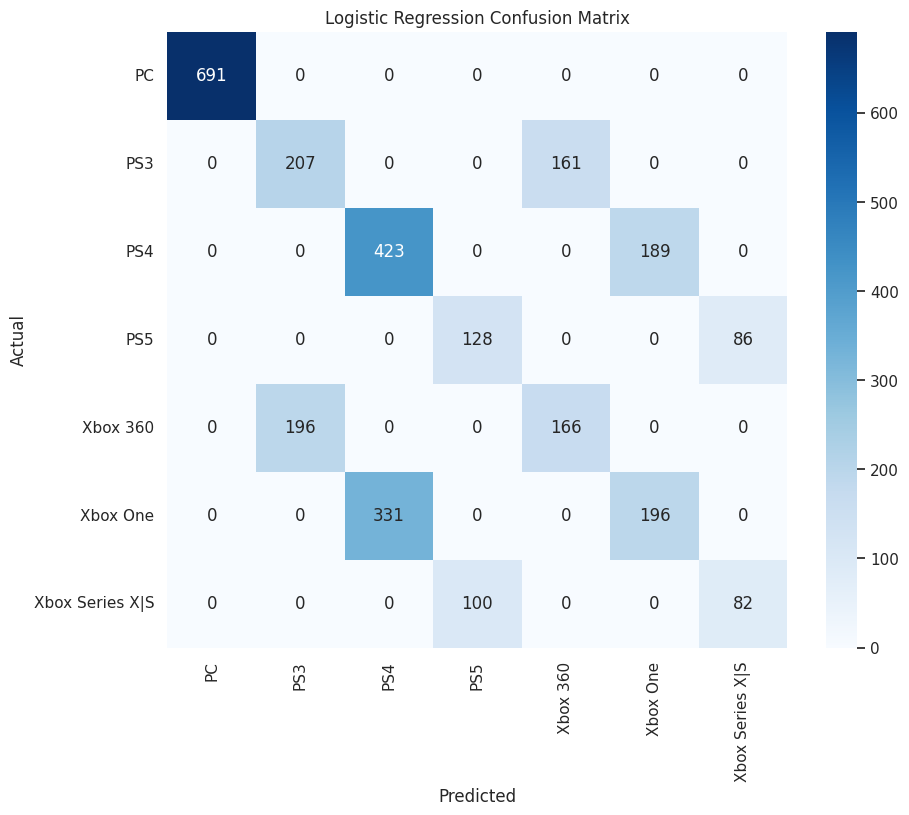

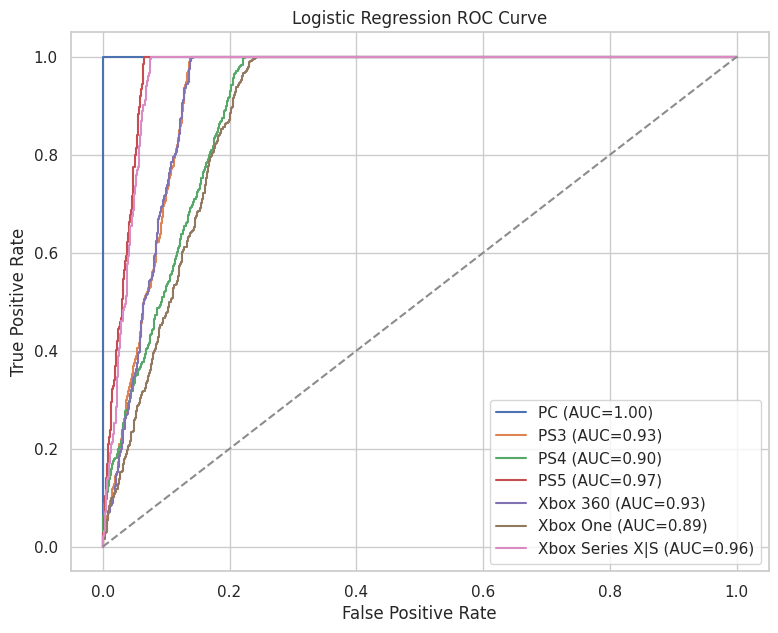

Decision Tree

Accuracy : 0.6430987821380244
Precision: 0.6434529943485057
Recall   : 0.6430987821380244
F1 Score : 0.6431626969573738

Classification Report

                 precision    recall  f1-score   support

             PC       1.00      1.00      1.00       691
            PS3       0.47      0.49      0.48       368
            PS4       0.59      0.58      0.59       612
            PS5       0.62      0.59      0.60       214
       Xbox 360       0.46      0.44      0.45       362
       Xbox One       0.52      0.53      0.53       527
Xbox Series X|S       0.54      0.57      0.56       182

       accuracy                           0.64      2956
      macro avg       0.60      0.60      0.60      2956
   weighted avg       0.64      0.64      0.64      2956



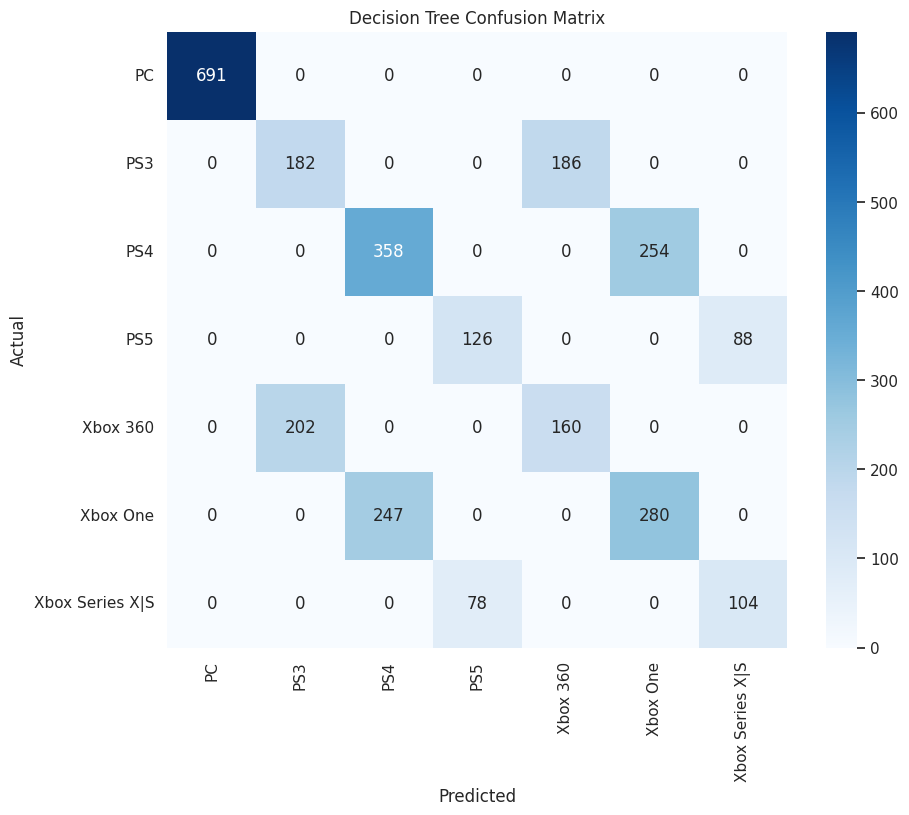

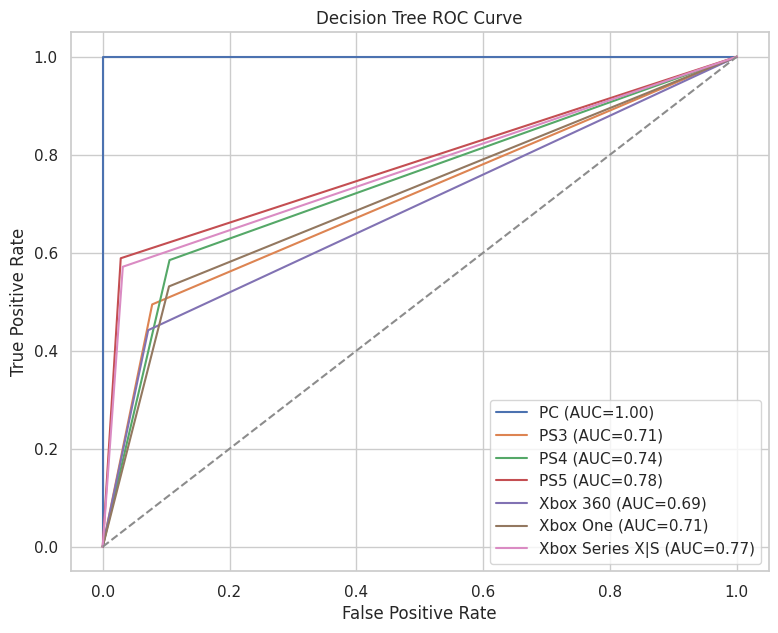

Random Forest

Accuracy : 0.6627198917456022
Precision: 0.6611040748927879
Recall   : 0.6627198917456022
F1 Score : 0.6596135920193172

Classification Report

                 precision    recall  f1-score   support

             PC       1.00      1.00      1.00       691
            PS3       0.52      0.53      0.53       368
            PS4       0.59      0.70      0.64       612
            PS5       0.60      0.66      0.63       214
       Xbox 360       0.51      0.50      0.50       362
       Xbox One       0.56      0.45      0.50       527
Xbox Series X|S       0.55      0.48      0.51       182

       accuracy                           0.66      2956
      macro avg       0.62      0.62      0.62      2956
   weighted avg       0.66      0.66      0.66      2956



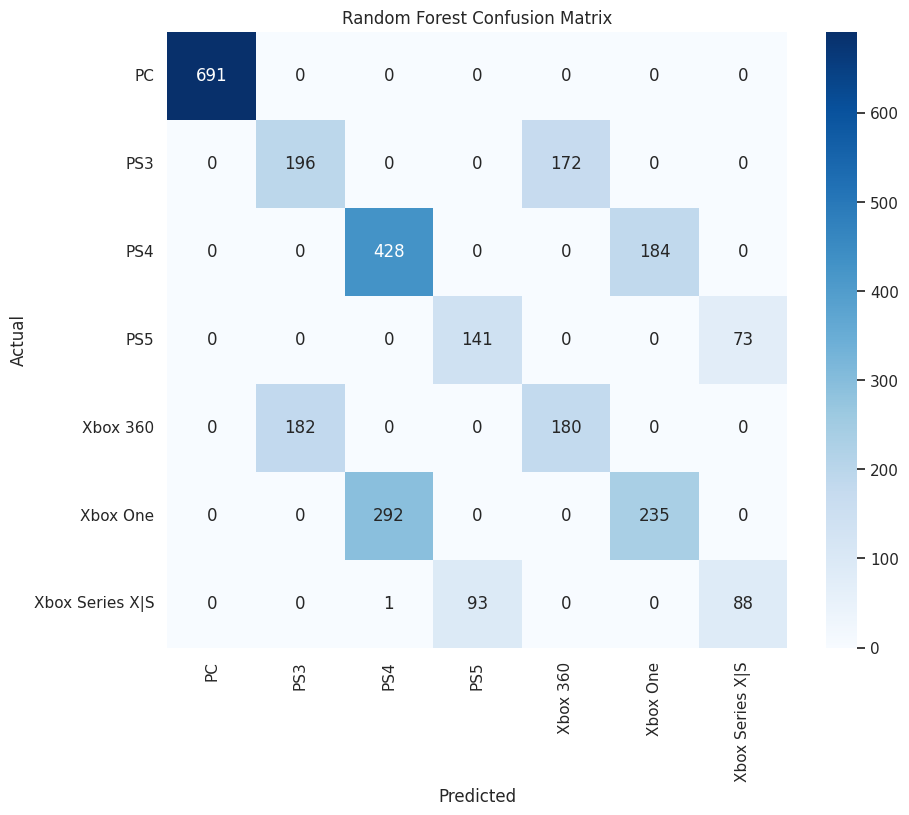

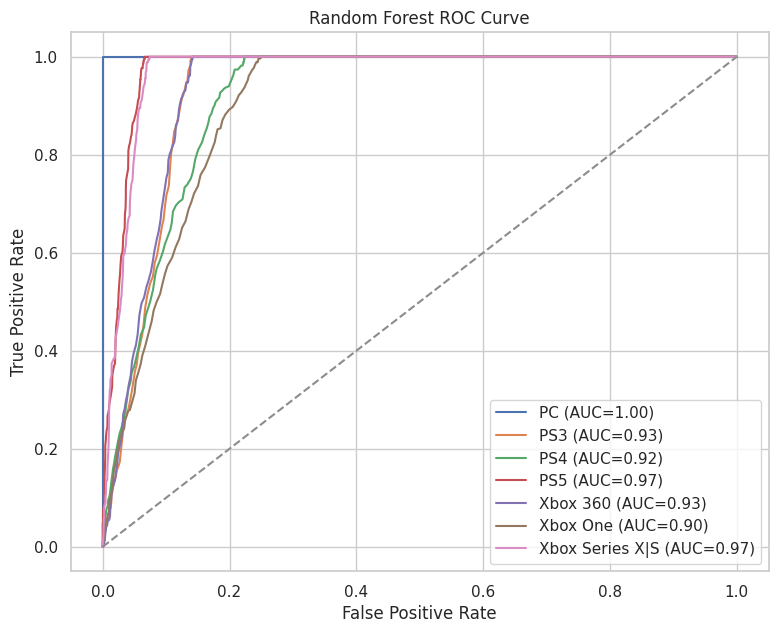

Gradient Boosting

Accuracy : 0.6853856562922869
Precision: 0.6848504894810374
Recall   : 0.6853856562922869
F1 Score : 0.6837124784492468

Classification Report

                 precision    recall  f1-score   support

             PC       1.00      1.00      1.00       691
            PS3       0.52      0.52      0.52       368
            PS4       0.64      0.73      0.68       612
            PS5       0.62      0.64      0.63       214
       Xbox 360       0.51      0.51      0.51       362
       Xbox One       0.63      0.53      0.57       527
Xbox Series X|S       0.56      0.54      0.55       182

       accuracy                           0.69      2956
      macro avg       0.64      0.64      0.64      2956
   weighted avg       0.68      0.69      0.68      2956



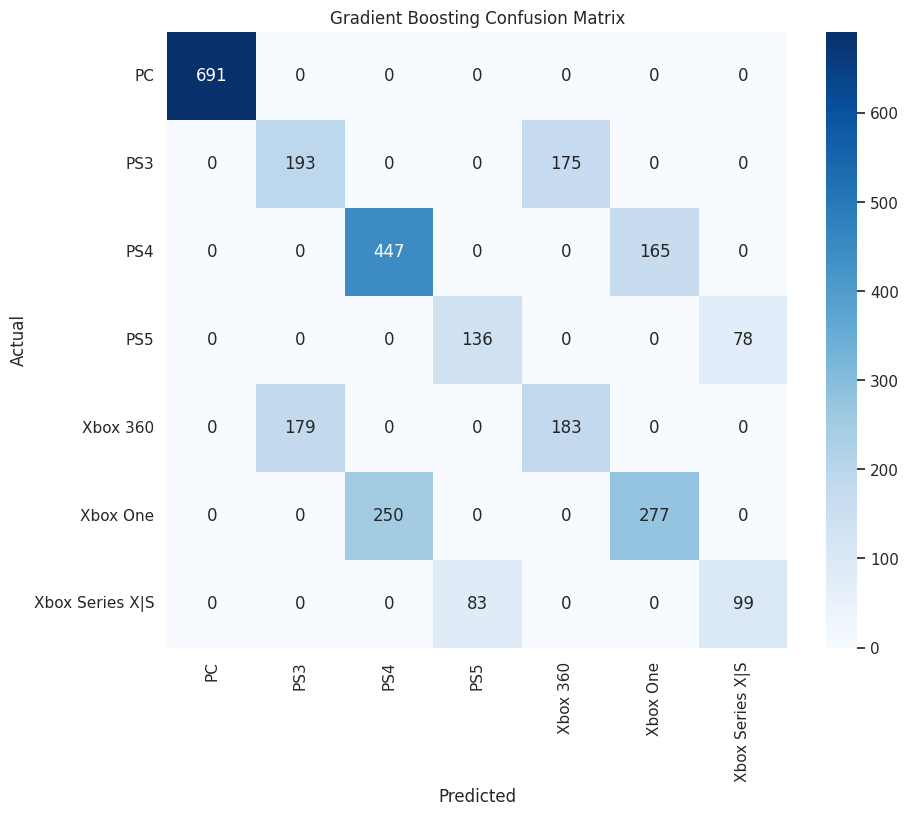

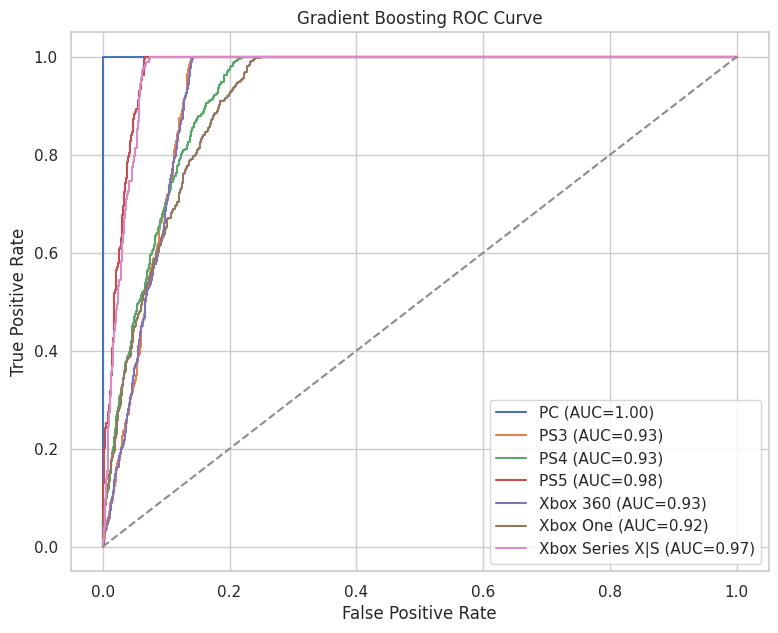

KNN

Accuracy : 0.5253721244925575
Precision: 0.5211739008968945
Recall   : 0.5253721244925575
F1 Score : 0.5188728166435818

Classification Report

                 precision    recall  f1-score   support

             PC       0.94      0.98      0.96       691
            PS3       0.35      0.45      0.39       368
            PS4       0.40      0.50      0.45       612
            PS5       0.50      0.48      0.49       214
       Xbox 360       0.38      0.30      0.34       362
       Xbox One       0.35      0.27      0.30       527
Xbox Series X|S       0.47      0.30      0.37       182

       accuracy                           0.53      2956
      macro avg       0.49      0.47      0.47      2956
   weighted avg       0.52      0.53      0.52      2956



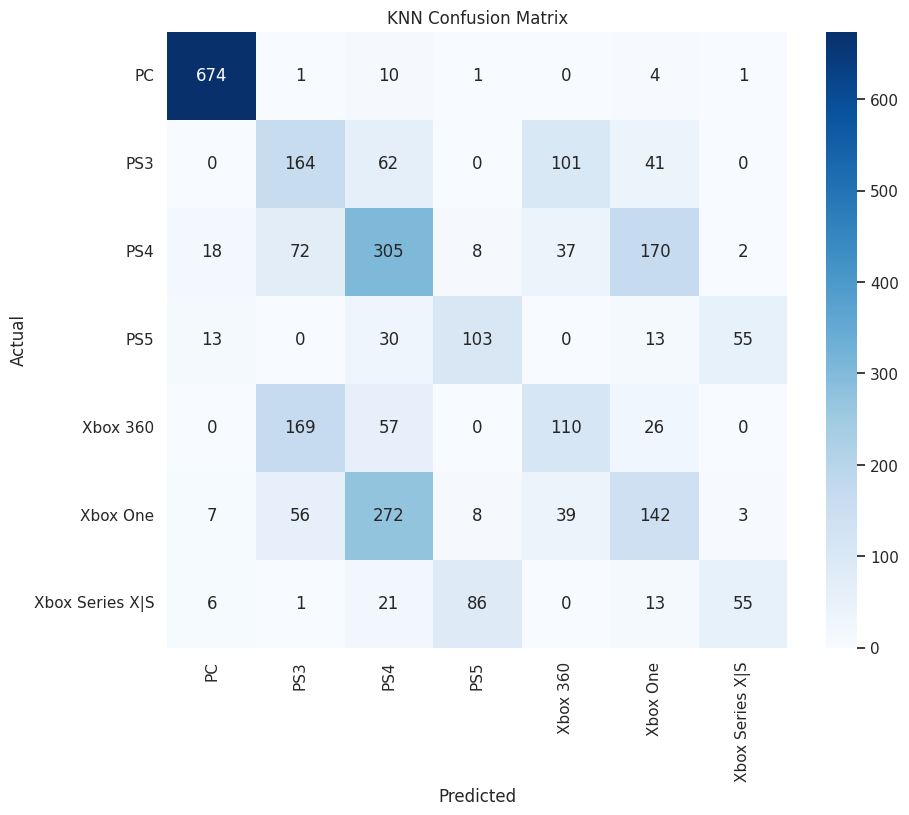

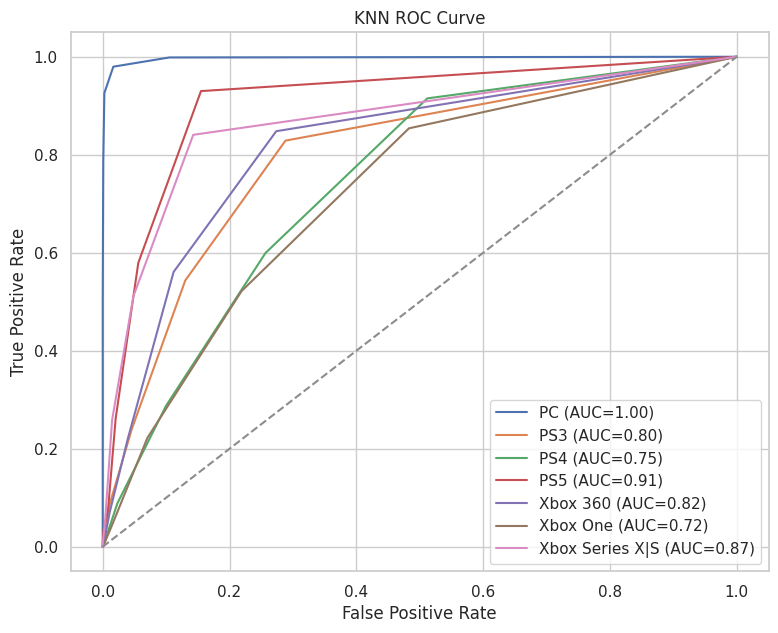

SVM

Accuracy : 0.6343031123139378
Precision: 0.630897665253879
Recall   : 0.6343031123139378
F1 Score : 0.6290088559291191

Classification Report

                 precision    recall  f1-score   support

             PC       1.00      1.00      1.00       691
            PS3       0.50      0.48      0.49       368
            PS4       0.56      0.69      0.62       612
            PS5       0.54      0.60      0.57       214
       Xbox 360       0.50      0.52      0.51       362
       Xbox One       0.51      0.37      0.43       527
Xbox Series X|S       0.46      0.40      0.43       182

       accuracy                           0.63      2956
      macro avg       0.58      0.58      0.58      2956
   weighted avg       0.63      0.63      0.63      2956



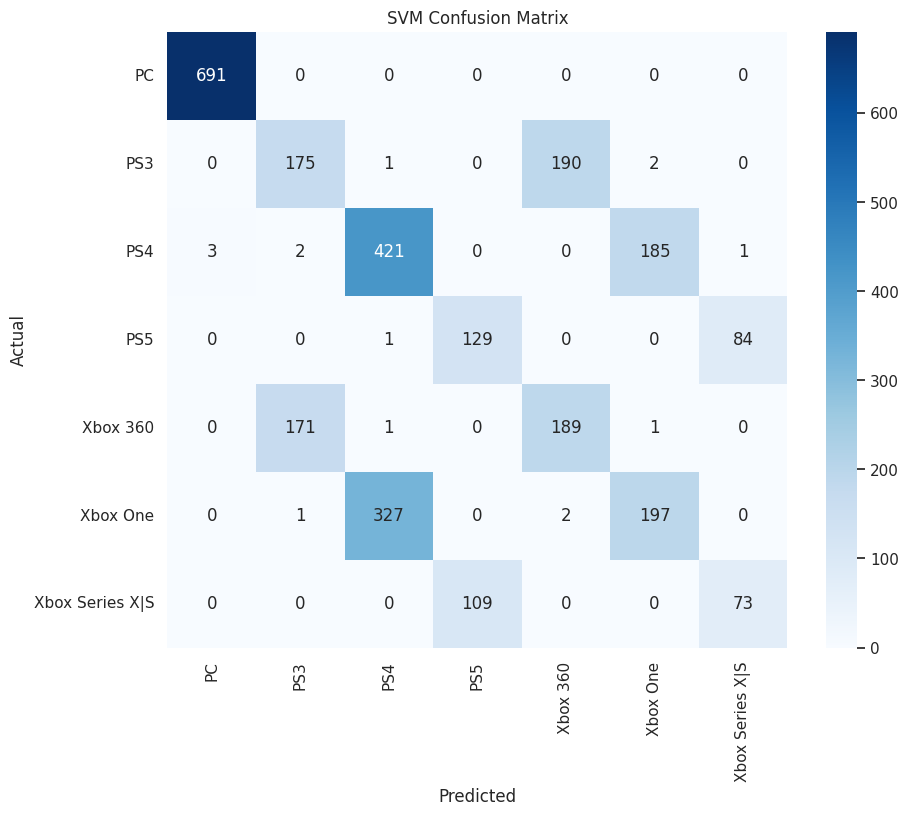

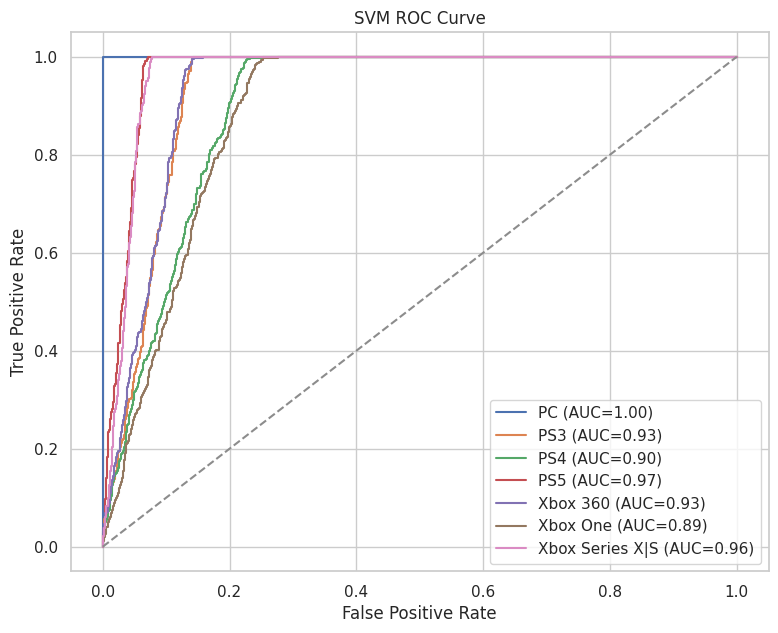

Naive Bayes

Accuracy : 0.6299052774018945
Precision: 0.6509845779957967
Recall   : 0.6299052774018945
F1 Score : 0.6047526584631822

Classification Report

                 precision    recall  f1-score   support

             PC       1.00      1.00      1.00       691
            PS3       0.56      0.23      0.32       368
            PS4       0.58      0.35      0.44       612
            PS5       0.67      0.20      0.30       214
       Xbox 360       0.51      0.81      0.63       362
       Xbox One       0.49      0.71      0.58       527
Xbox Series X|S       0.48      0.88      0.63       182

       accuracy                           0.63      2956
      macro avg       0.61      0.60      0.56      2956
   weighted avg       0.65      0.63      0.60      2956



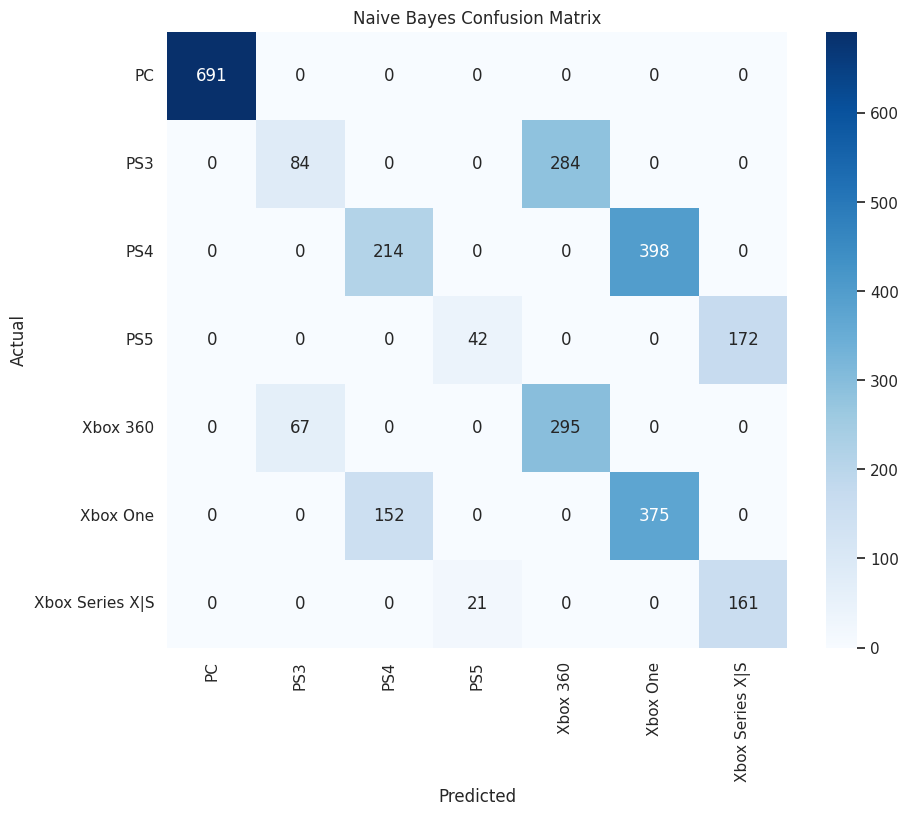

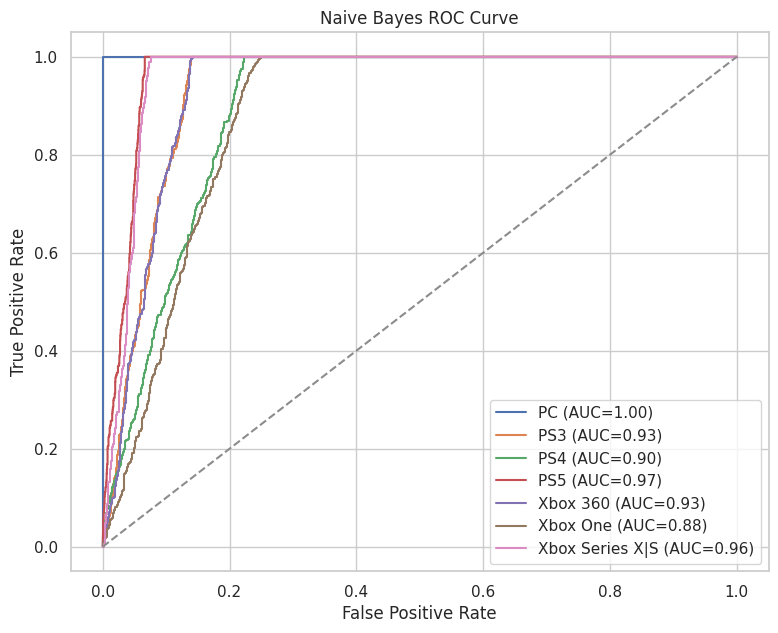


FINAL MODEL COMPARISON

                 Model  Accuracy  Precision    Recall  F1 Score
3    Gradient Boosting  0.685386   0.684850  0.685386  0.683712
2        Random Forest  0.662720   0.661104  0.662720  0.659614
1        Decision Tree  0.643099   0.643453  0.643099  0.643163
0  Logistic Regression  0.640392   0.637480  0.640392  0.635253
5                  SVM  0.634303   0.630898  0.634303  0.629009
6          Naive Bayes  0.629905   0.650985  0.629905  0.604753
4                  KNN  0.525372   0.521174  0.525372  0.518873

Best Performing Model
Model        Gradient Boosting
Accuracy              0.685386
Precision              0.68485
Recall                0.685386
F1 Score              0.683712
Name: 3, dtype: object


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ============================================================
# COPY DATASET
# ============================================================

data = df.copy()

# ============================================================
# REMOVE ID COLUMN
# ============================================================

data.drop(columns=["transaction_id"], inplace=True)

# ============================================================
# TARGET VARIABLE
# ============================================================

target = "platform"

X = data.drop(columns=[target])
y = data[target]

# ============================================================
# TRAIN TEST SPLIT (NO DATA LEAKAGE)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# LABEL ENCODE TARGET ONLY
# ============================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

n_classes = len(target_encoder.classes_)

# ============================================================
# FIND CATEGORICAL & NUMERICAL COLUMNS
# ============================================================

categorical_cols = X_train.select_dtypes(include=["object"]).columns

numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

X_train = X_train.copy()
X_test = X_test.copy()

feature_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    feature_encoders[col] = le

    X_test[col] = X_test[col].astype(str)

    X_test[col] = X_test[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(probability=True),

    "Naive Bayes":
        GaussianNB()

}

# ============================================================
# MODEL TRAINING
# ============================================================

results = []

for name, model in models.items():

    print("="*80)
    print(name)
    print("="*80)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")
    print(classification_report(
        y_test,
        predictions,
        target_names=target_encoder.classes_
    ))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ==========================================================
    # ROC CURVE
    # ==========================================================

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(X_test)

        y_test_bin = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        plt.figure(figsize=(9,7))

        for i in range(n_classes):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                probabilities[:, i]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})"
            )

        plt.plot(
            [0,1],
            [0,1],
            linestyle="--"
        )

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.title(name + " ROC Curve")

        plt.legend()

        plt.show()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# ============================================================
# FINAL RESULT TABLE
# ============================================================

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nFINAL MODEL COMPARISON\n")

print(results)

# ============================================================
# BEST MODEL
# ============================================================

best_model = results.iloc[0]

print("\nBest Performing Model")
print(best_model)

## Thanks...........Please Upvote